In [2]:
import cme.decision_models.confidence_accumulation as ca
import cme.decision_models.quantum_discrete as qd
import cme.decision_models.diffusion_discrete as dd
import cme.utils.common_utils as cu

import jax.numpy as npx
import jax.scipy as scx
import pandas as pd
import seaborn as sns
import numpy as np
import scipy as sci
import seaborn.objects as so
import matplotlib.pyplot as plt
import cme.simulators.diffusion_random_walk as drw

#sns.set_context("paper", font_scale=2.5)
import plotly.io as pio
pio.renderers


Renderers configuration
-----------------------
    Default renderer: 'plotly_mimetype+notebook'
    Available renderers:
        ['plotly_mimetype', 'jupyterlab', 'nteract', 'vscode',
         'notebook', 'notebook_connected', 'kaggle', 'azure', 'colab',
         'cocalc', 'databricks', 'json', 'png', 'jpeg', 'jpg', 'svg',
         'pdf', 'browser', 'firefox', 'chrome', 'chromium', 'iframe',
         'iframe_connected', 'sphinx_gallery', 'sphinx_gallery_png']

In [3]:
n_states, start_width, response_width, delta, measurement_prob,  I, J, steps = 11, 5, 2, 0.1, 1, 1, 1, 0.1
m_Mc, m_Mw, m_Mn = ca._get_measurement_matrix(n_states, 1, prob=measurement_prob, model_type = "Markov")
q_Mc, q_Mw, q_Mn = ca._get_measurement_matrix(n_states, 1, prob=measurement_prob, model_type = "Quantum")
mv_arr = cu.get_conf_limits(n_states)

In [4]:
add_scale, mul_scale = 0,1

In [5]:
m_mu, m_sigma, T = npx.asarray([[1]]), npx.asarray([[1]]), 100
q_mu, q_sigma, T = npx.asarray([[2]]), npx.asarray([[3]]), 100

intensity_matrix_markov = dd._buildK(n_states, m_mu, m_sigma)
intensity_matrix_quantum = qd._buildH(n_states, q_mu, q_sigma)


In [6]:
intensity_matrix_markov.squeeze()

Array([[-1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 1., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  1., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  1., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  1., -1.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  1., -1.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  1., -1.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  1., -1.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  1., -1.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1., -1.,  1.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1., -1.]],      dtype=float64)

In [7]:
theta, alpha, tau = 0.9, 1.5, 0.01

mu, sigma_coef = np.asarray([2]), np.asarray([1])

n_states = drw.get_n_states(alpha, theta, tau, sigma_coef)
discrete_transition_matrix = drw.get_transition_matrix(alpha, tau, sigma_coef[0], mu, process="Wiener", n_states=n_states).round(decimals=2)
discrete_transition_matrix.shape

(11, 11)

In [8]:
sns.color_palette("Blues")[1:]

[(0.7309496347558632, 0.8394771241830065, 0.9213225682429834),
 (0.5356862745098039, 0.746082276047674, 0.8642522106881968),
 (0.32628988850442137, 0.6186236063052672, 0.802798923490965),
 (0.16696655132641292, 0.48069204152249134, 0.7291503267973857),
 (0.044059976931949255, 0.3338869665513264, 0.6244521337946944)]

Text(0.5, 1.0, 'Discrete Time')

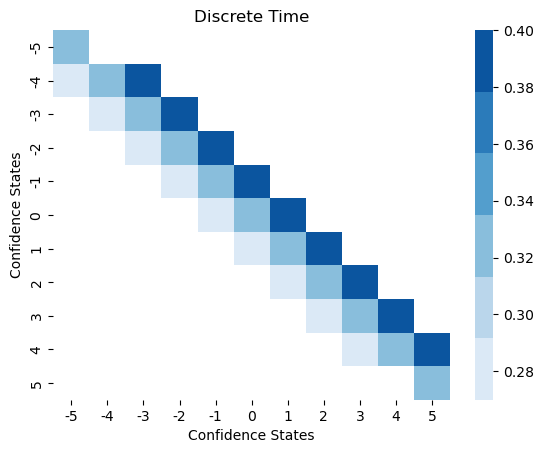

In [9]:
ax = sns.heatmap(np.where(discrete_transition_matrix.squeeze()==0,np.nan,discrete_transition_matrix.squeeze()) ,
    cmap = sns.color_palette("Blues"), xticklabels=mv_arr, yticklabels=mv_arr)
ax.set_xlabel("Confidence States")
ax.set_ylabel("Confidence States")
ax.set_title("Discrete Time")

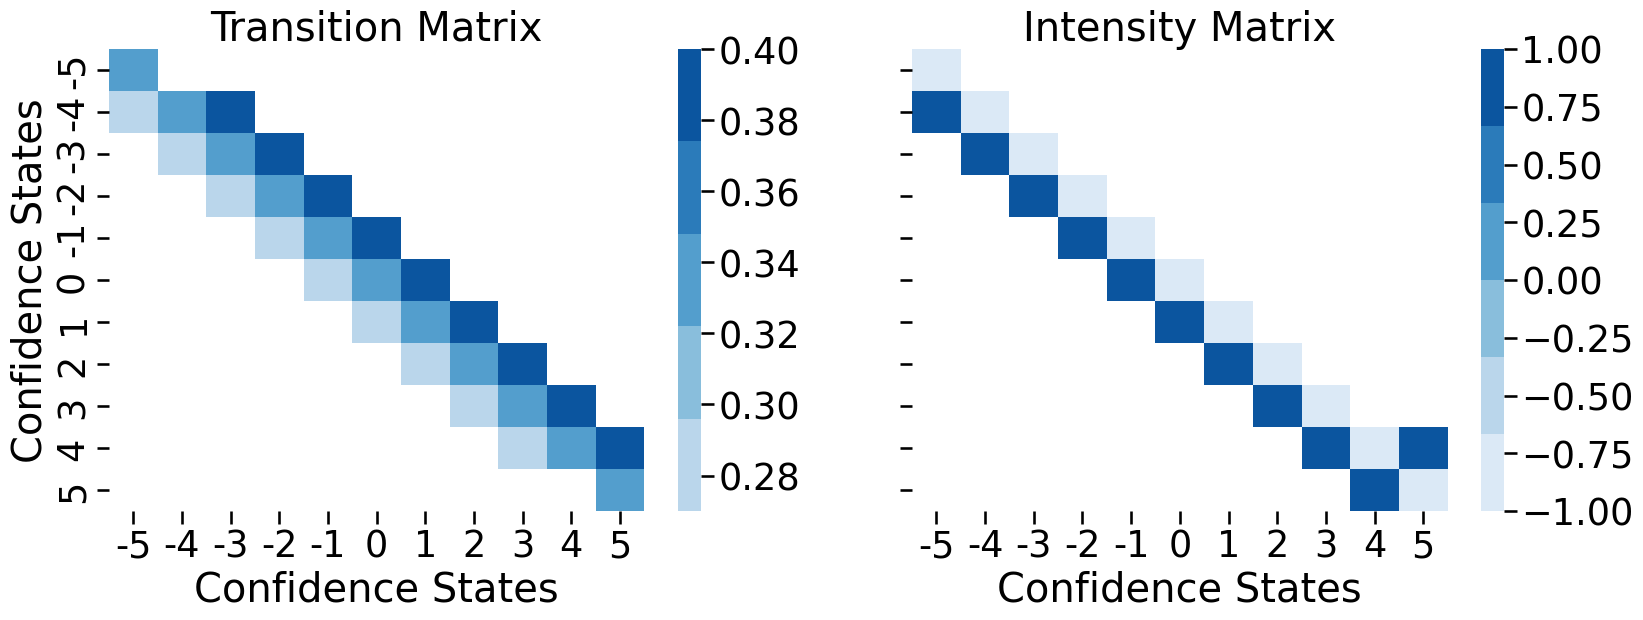

In [10]:
with sns.plotting_context("talk", font_scale=1.6):
    fig, axs = plt.subplots(1,2, figsize=(19,6), sharex=True, sharey=True)
    sns.heatmap(np.where(discrete_transition_matrix==0,np.nan,discrete_transition_matrix),  
    cmap = sns.color_palette("Blues")[1:], ax=axs[0], xticklabels=mv_arr, yticklabels=mv_arr)
    axs[0].set_title("Transition Matrix")
    sns.heatmap(np.where(intensity_matrix_markov.squeeze()==0,np.nan,intensity_matrix_markov.squeeze()) ,
    cmap = sns.color_palette("Blues"), ax=axs[1], xticklabels=mv_arr, yticklabels=mv_arr)
    axs[1].set_title("Intensity Matrix")
    axs[0].set_xlabel("Confidence States")
    axs[1].set_xlabel("Confidence States")
    axs[0].set_ylabel("Confidence States")


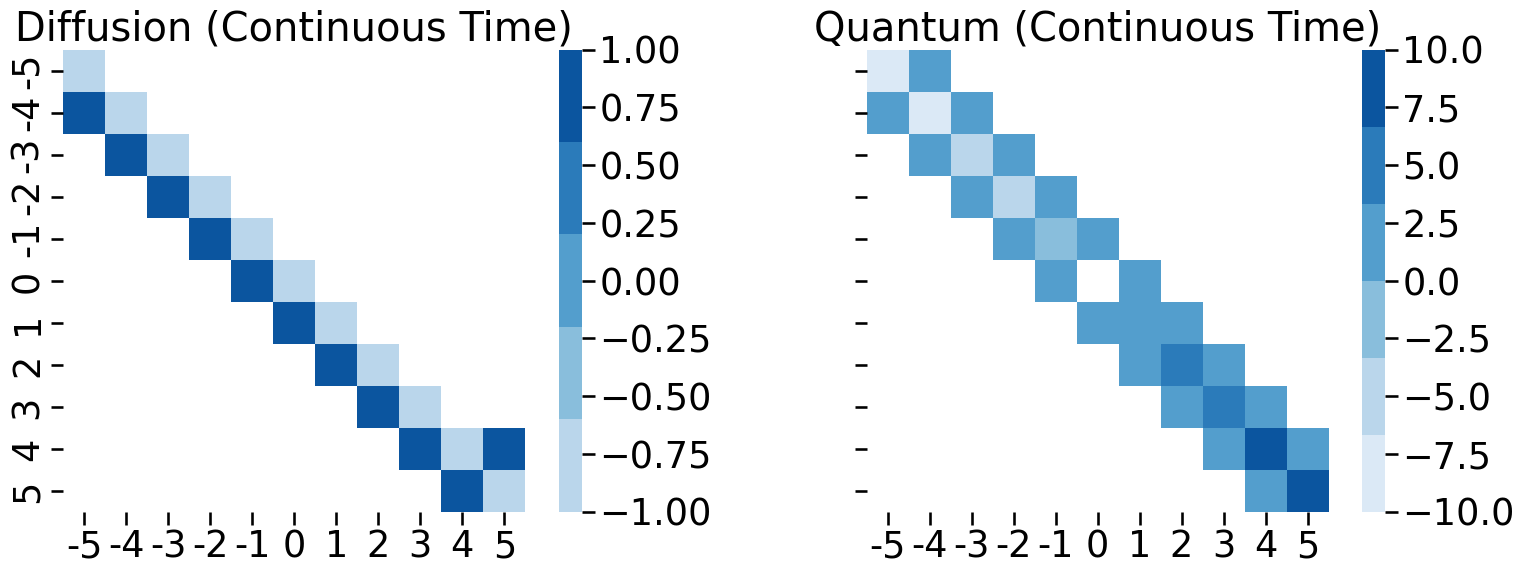

In [11]:
with sns.plotting_context("talk", font_scale=1.6):
    fig, axs = plt.subplots(1,2, figsize=(19,6), sharex=True, sharey=True)
   
    sns.heatmap(np.where(intensity_matrix_markov.squeeze()==0,np.nan,intensity_matrix_markov.squeeze()) ,
    cmap = sns.color_palette("Blues")[1:], ax=axs[0], xticklabels=mv_arr, yticklabels=mv_arr, square=True)
    axs[0].set_title("Diffusion (Continuous Time)")
    #axs[0].set_xlabel("Confidence States")
    #axs[1].set_xlabel("Confidence States")
    #axs[0].set_ylabel("Confidence States")
    intensity_t = -np.imag(intensity_matrix_quantum.squeeze())
    sns.heatmap(np.where(intensity_t==0,np.nan,intensity_t), cmap = sns.color_palette("Blues"), 
                ax=axs[1], xticklabels=mv_arr, yticklabels=mv_arr, square=True)
    axs[1].set_title("Quantum (Continuous Time)")

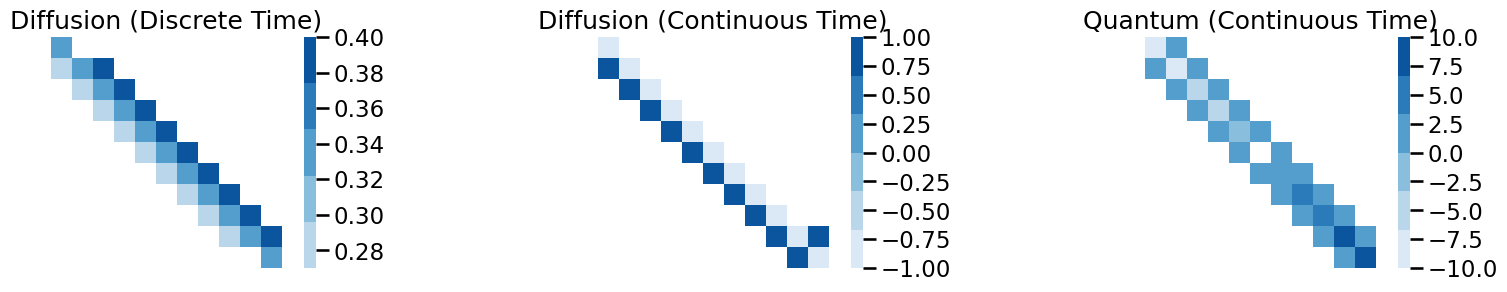

In [12]:
with sns.plotting_context("talk", font_scale=1):
    fig, axs = plt.subplots(1,3, figsize=(20,3), sharex=True, sharey=True)
    sns.heatmap(np.where(discrete_transition_matrix==0,np.nan,discrete_transition_matrix),  
    cmap = sns.color_palette("Blues")[1:], ax=axs[0], xticklabels=[], yticklabels=[], square=True)
    axs[0].set_title("Diffusion (Discrete Time)")
    sns.heatmap(np.where(intensity_matrix_markov.squeeze()==0,np.nan,intensity_matrix_markov.squeeze()) ,
    cmap = sns.color_palette("Blues"), ax=axs[1], xticklabels=[], yticklabels=[], square=True)
    axs[1].set_title("Diffusion (Continuous Time)")
    #axs[0].set_xlabel("Confidence States")
    #axs[1].set_xlabel("Confidence States")
    #axs[0].set_ylabel("Confidence States")
    intensity_t = -np.imag(intensity_matrix_quantum.squeeze())
    sns.heatmap(np.where(intensity_t==0,np.nan,intensity_t), cmap = sns.color_palette("Blues"), 
                ax=axs[2], xticklabels=[], yticklabels=[], square=True)
    axs[2].set_title("Quantum (Continuous Time)")
    


In [13]:
n_states, start_width, response_width

(11, 5, 2)

In [14]:
response_width = 6

In [15]:
phi_0_markov = ca._get_initial_state(n_states, start_width, response_width, model_type="Markov", prior_type="Centered")
phi_0_quantum = ca._get_initial_state(n_states, start_width, response_width, model_type="Quantum" , prior_type="Centered")
phi_0_markov, phi_0_quantum

(Array([[[[0. ],
          [0. ],
          [0. ],
          [0.2],
          [0.2],
          [0.2],
          [0.2],
          [0.2],
          [0. ],
          [0. ],
          [0. ]]]], dtype=float64),
 Array([[[[0.       ],
          [0.       ],
          [0.       ],
          [0.4472136],
          [0.4472136],
          [0.4472136],
          [0.4472136],
          [0.4472136],
          [0.       ],
          [0.       ],
          [0.       ]]]], dtype=float64))

In [16]:
ca._get_initial_state(11, 11,response_width, model_type="Quantum", prior_type="Centered")

Array([[[[0.30151134],
         [0.30151134],
         [0.30151134],
         [0.30151134],
         [0.30151134],
         [0.30151134],
         [0.30151134],
         [0.30151134],
         [0.30151134],
         [0.30151134],
         [0.30151134]]]], dtype=float64)

In [17]:
T/delta

1000.0

In [111]:
likl_markov_arr = []
likl_quantum_arr = []

#m_mu1, m_sigma1, delta, T = npx.asarray([[0.56]]), npx.asarray([[20.09]]), 0.1, 40
m_mu1, m_sigma1, delta, T = npx.asarray([[1.3099718]]), npx.asarray([[8.859912]]), 0.1, 8

q_mu1, q_sigma1, delta, T = npx.asarray([[2]]), npx.asarray([[1]]), 0.1, 8
#q_mu1, q_sigma1, delta, T = npx.asarray([[1]]), npx.asarray([[2]]), 0.1, 70

#for n, _, r in zip([11,21,31,41,51], [5,17,25,33,41], [1,2,3,4,5]):
for n, _, r in zip([11,51,101], [5,41, 51], [1,5,10]):
    #Mid = (n+1)//2
    Mid1 = (n-2*r)
    Mid2 = (n-2*r)//2
    Mid3 = Mid2-3
    
    print(n,2*r,"| Centered",Mid1," | Half of Centered",Mid2)
    for w, w_n in zip([Mid3, Mid2, Mid1], ["Lesser","Less", "All"]):
     
        phi_0_markov1 = ca._get_initial_state(n, w,r,model_type="Markov", prior_type="Centered")
        phi_0_quantum1 = ca._get_initial_state(n, w,r,model_type="Quantum" , prior_type="Centered")

        intensity_matrix_markov1 = dd._buildK(n, m_mu1, m_sigma1)
        intensity_matrix_quantum1 = qd._buildH(n, q_mu1, q_sigma1)

        m_Mc1, m_Mw1, m_Mn1 = ca._get_measurement_matrix(n, r, prob=0.5, model_type = "Markov")
        q_Mc1, q_Mw1, q_Mn1 = ca._get_measurement_matrix(n, r, prob=0.5, model_type = "Quantum")

        import scipy as sci
        
        for t in np.arange(0,T/delta,delta):
            likl_markov = ca.likelihood(intensity_matrix=intensity_matrix_markov1, phi_0=phi_0_markov1, delta=delta,
                                    RT_s=npx.asarray([[t]]), RA_s=npx.asarray([[1]]),  
                                    Mc=m_Mc1, Mw=m_Mw1, Mn=m_Mn1, 
                                    transition_type="TIMESTEP", likelihood_type="SINGLE", model_type="Markov")
            likl_markov_arr.append(pd.DataFrame({"likl":(np.array(likl_markov).sum()), "model":"Markov", "time":[t*delta], "states":n, "ws":w, "ws_n":w_n}))
            
            likl_quantum = ca.likelihood(intensity_matrix=intensity_matrix_quantum1, phi_0=phi_0_quantum1, delta=delta,
                                    RT_s=npx.asarray([[t]]), RA_s=npx.asarray([[1]]),
                                    Mc=q_Mc1, Mw=q_Mw1, Mn=q_Mn1, 
                                    transition_type="TIMESTEP", likelihood_type="SINGLE", model_type="Quantum")

            likl_quantum_arr.append(pd.DataFrame({"likl":(np.array(likl_quantum).sum()), "model":"Quantum", "time":[t*delta], "states":n, "ws":w, "ws_n":w_n}))

        #pd.DataFrame({"likl":likl_markov.squeeze(), "model":"Markov"})
        #pd.Series(npx.asarray(likl_quantum_arr), name="Quantum").plot()
        #plt.legend()
        #plt.show()
df_markov_plot_n = pd.concat(likl_markov_arr).astype({"states":"category"})
df_quantum_plot_n = pd.concat(likl_quantum_arr).astype({"states":"category"})
df_plot_n = pd.concat([df_markov_plot_n.assign(model="Diffusion"), df_quantum_plot_n.assign(model="Quantum")])


11 2 | Centered 9  | Half of Centered 4


51 10 | Centered 41  | Half of Centered 20
101 20 | Centered 81  | Half of Centered 40


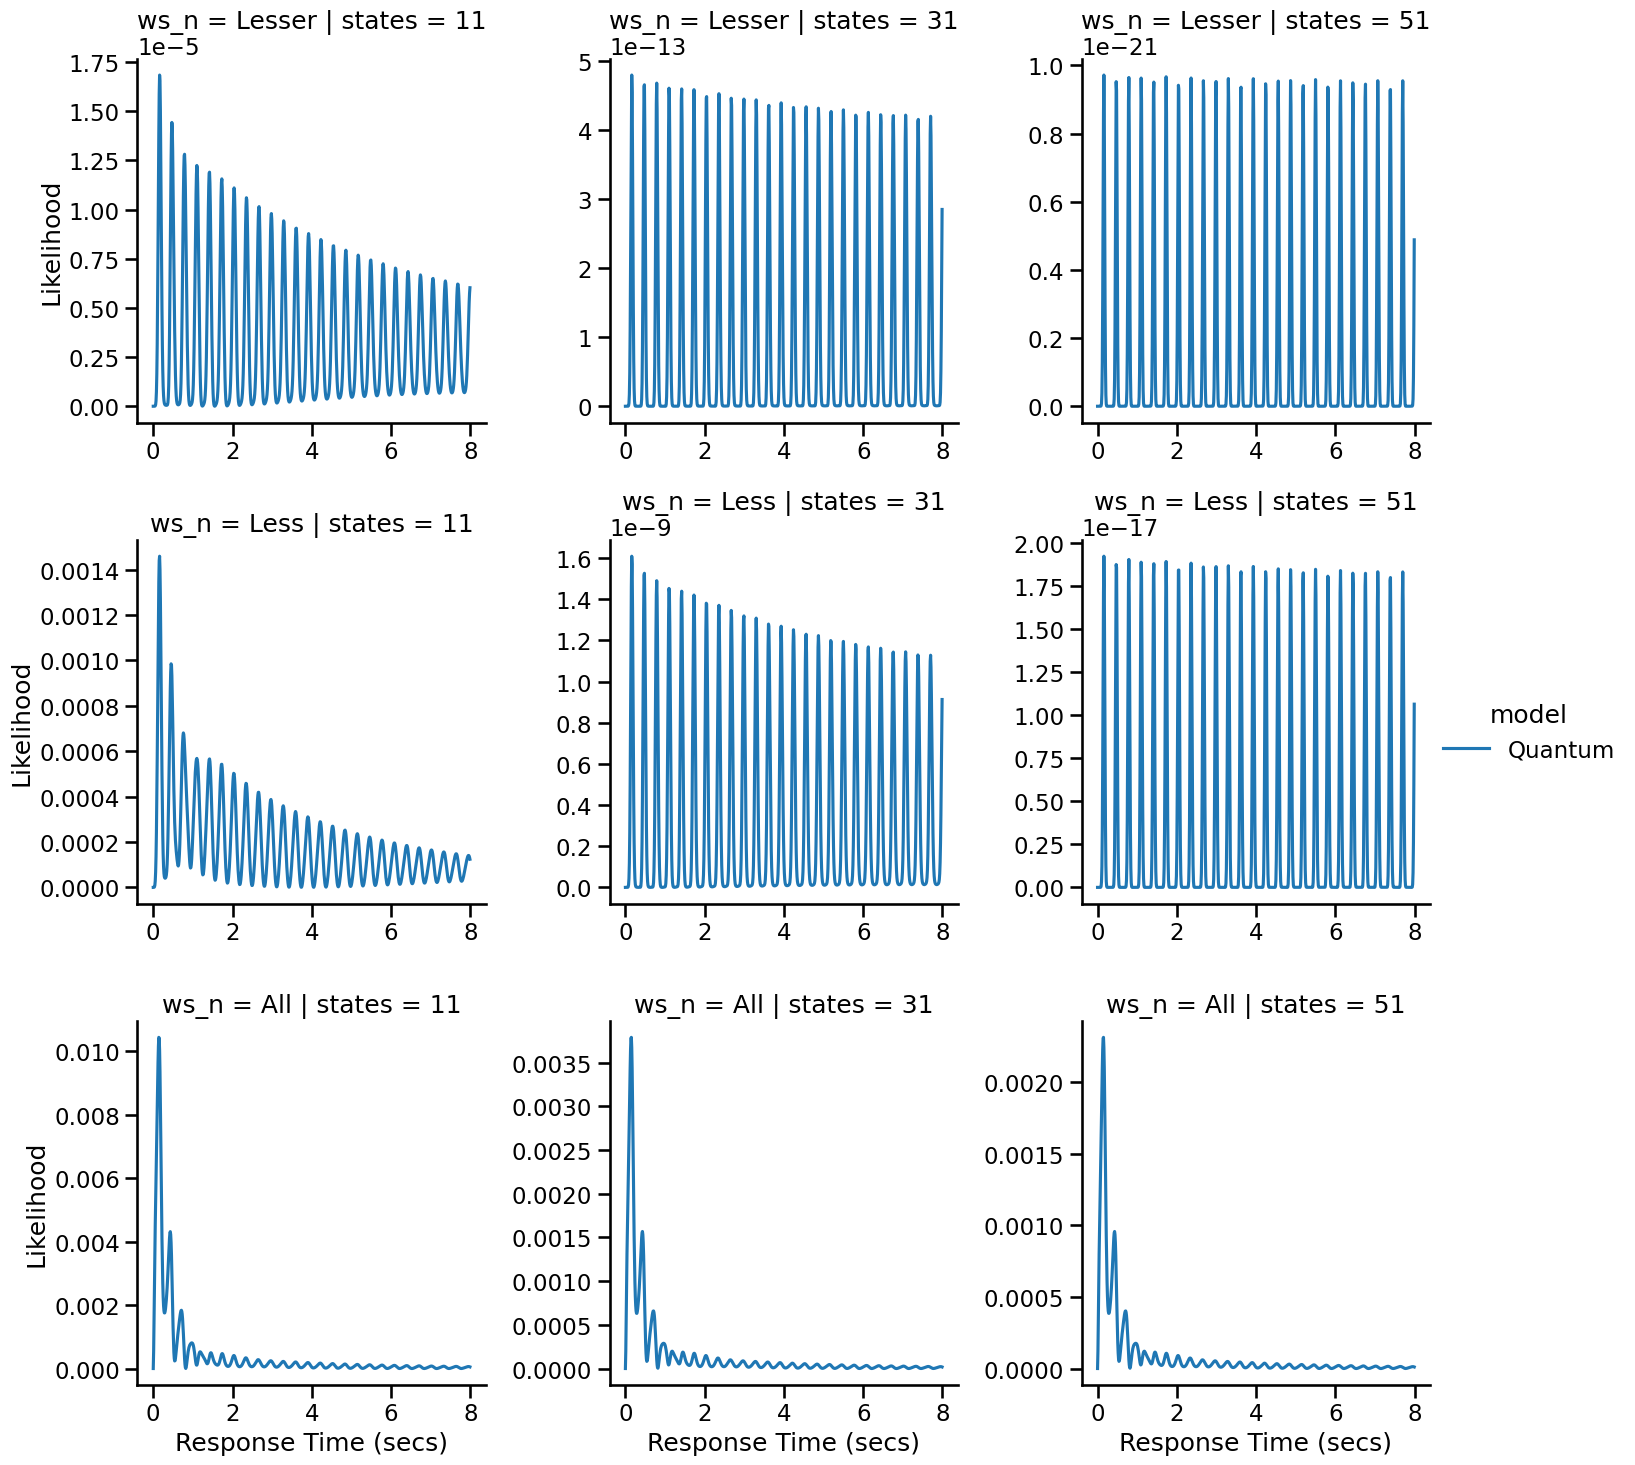

In [66]:
with sns.plotting_context("talk", font_scale=1):
    f = sns.relplot(df_plot_n.query("model=='Quantum'"),
    x="time", y="likl", row="ws_n", col="states", aspect=1, hue="model",
    kind="line", facet_kws={"sharey":False, "sharex":False})
    f.set_axis_labels(x_var="Response Time (secs)", y_var="Likelihood")
    #f.set_titles("States: {col_name}", size=20)

df_plot_sample = df_plot_n.assign(likl=lambda df:np.abs(df.likl)).groupby(["model","states","ws_n"]).sample(frac=1,replace=True,weights="likl")
df_plot_sample

sns.displot(df_plot_sample, x="time", hue="states",col="model",row="ws_n", kind="kde")

with sns.plotting_context("talk", font_scale=1):
    f = sns.relplot(df_plot_n.query("model=='Quantum'"),
    x="time", y="likl", row="ws_n", col="states", #aspect=2, height=10,
    kind="line", facet_kws={"sharey":False, "sharex":False})
    f.set_axis_labels(x_var="Response Time (secs)", y_var="Likelihood")
    #f.set_titles("State: {col_name}", size=20)

/tmp/ipykernel_8019/2740691594.py:2: RuntimeWarning:

Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.



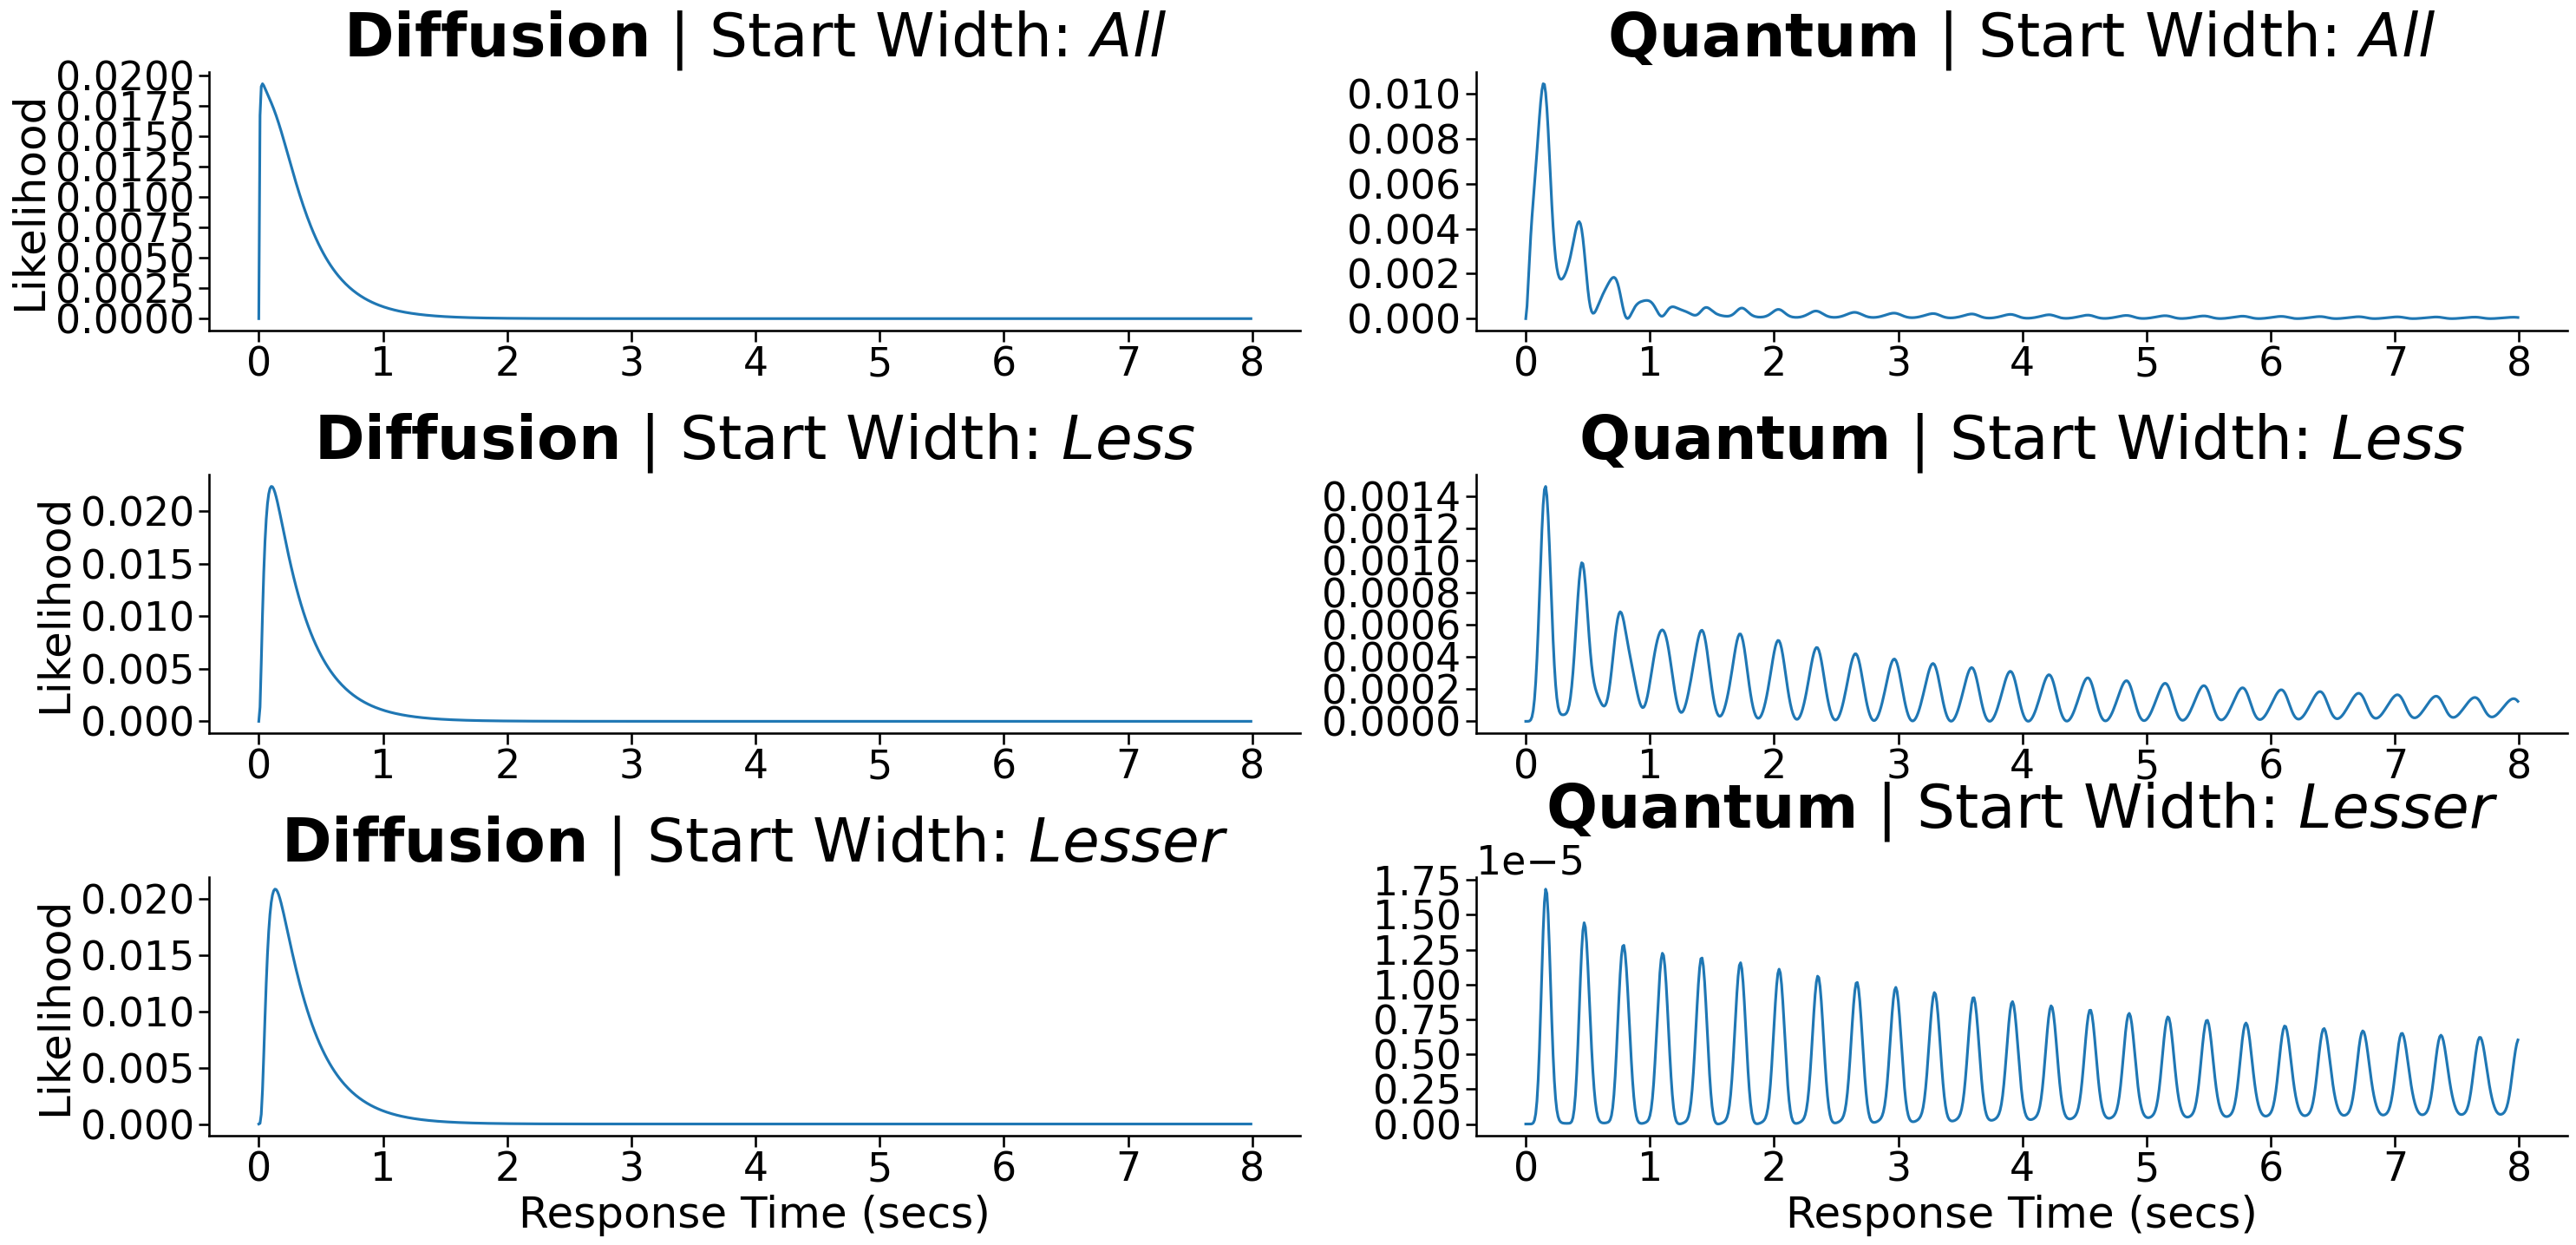

In [112]:
with sns.plotting_context("talk", font_scale=2):
    f = sns.relplot(df_plot_n.query("states==11"),
    x="time", y="likl", col="model", aspect=3, row="ws_n", row_order=["All", "Less", "Lesser"],
    kind="line", facet_kws={"sharey":False, "sharex":False})
    f.set_axis_labels(x_var="Response Time (secs)", y_var="Likelihood")
    f.set_titles(r"$\bf{{{col_name}}}$ | Start Width: ${row_name}$", size=50)


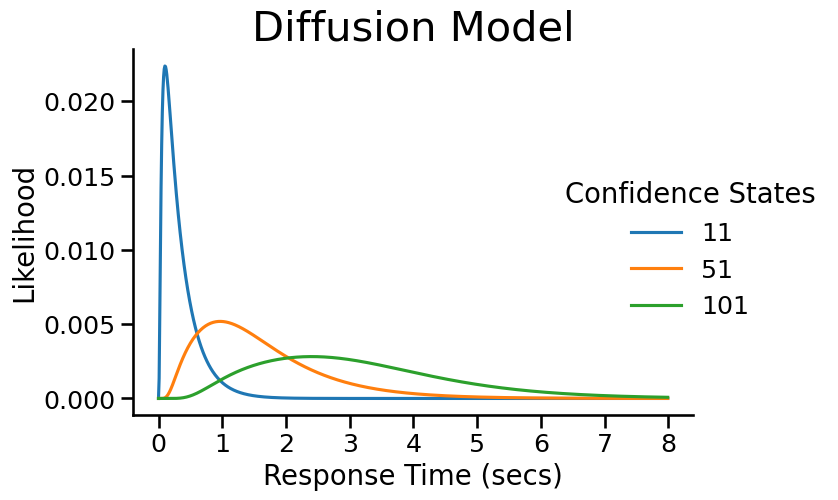

In [113]:
with sns.plotting_context("talk", font_scale=1.1):
    f = sns.relplot(df_plot_n.query("ws_n == 'Less' and model=='Diffusion'"),
    x="time", y="likl", aspect=1.5, hue="states", #col="model", 
    kind="line", facet_kws={"sharey":False, "sharex":False})
    f.set_axis_labels(x_var="Response Time (secs)", y_var="Likelihood")
    f.legend.set_title("Confidence States")
    #f.set_titles("{col_name}", size=40)
    f.ax.set_title("Diffusion Model", size=30)

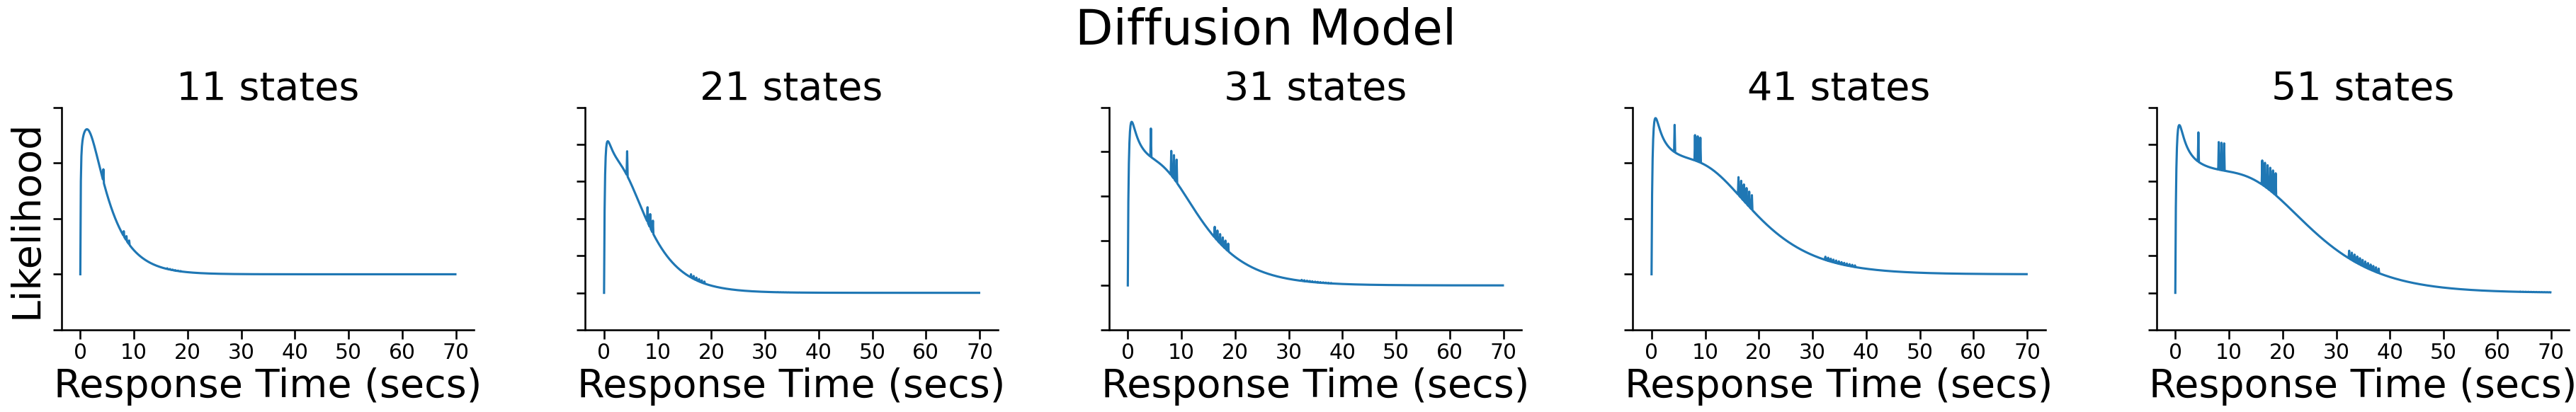

In [21]:
with sns.plotting_context("talk", font_scale=1.3):
    f = sns.relplot(df_plot_n.query("ws_n=='Centered' and model=='Diffusion'"),
    x="time", y="likl", row="model", aspect=1.5, col="states",
    kind="line", facet_kws={"sharey":False, "sharex":False})
    f.set_axis_labels(x_var="Response Time (secs)", y_var="Likelihood", size=40)
    f.set_titles("{col_name} states", size=40)
    f.figure.suptitle("Diffusion Model", fontsize=50, y=1.15)
    f.set_yticklabels([])


In [89]:
def _buildH(m,a,b,c): 
# H = buildH(a,b,c)
# m = number of states  
# a = off diag left  
# b = diag  
# c = off diag right


    H = np.zeros((m, m))
    H[0,0] = b[0]
    H[0,1] = c[0]
    H[m-1, m-2] = a[m-1]
    H[m-1, m-1] = b[m-1]

    for k in range(1,m-1):
        H[k,k-1] = a[k]
        H[k,k] = b[k]
        H[k,k+1] = c[k]

    return H

mu=2
ap=1
delta2=0.1
T2 = 70
import itertools as iter
# Quantum working values ns, ws, rw  = [101], [40], [10], prob=0.25 tv = np.arange(0,30,0.1)
df_quantum_plot_n1 = []
df_quantum_plot_all_states = []
#for ns, ws, rw, prob in zip([11, 51, 101], [4, 20, 40], [1, 5, 10], [0.8,0.5,0.25]): produces exact same results
#for (ns, ws, rw), prob in iter.product (zip([5, 7, 11, 51, 101], [1,2, 4, 20, 40], [1, 1, 1, 5, 10]), [0.1,0.2,0.3]): #produces exact same results
#for (ns, rw), prob in iter.product (zip([11, 21, 51], [1,2, 4]), [0.05, 0.5, 0.85,1]):
for (ns, rw), prob in iter.product (zip([11, 51,101], [1, 5, 10]), [0.5]):
#for (ns, rw), prob in iter.product (zip([11], [1]), [0.5]):
    Mid = (ns+1)//2
    Mid1 = (ns-2*rw)//2 #here divide by two is needed given the way mid is calculated. it just means all no response states.
    print("****",ns, rw, Mid1)
    mv = np.arange(-(Mid-1), (Mid))
    
    for ws, ws_n in zip([Mid1-3, Mid1-1, Mid1], ["Fewer Less", "Few Less", "All Non-Response States"]):
    #for ws, ws_n in zip([0, 1, 4], ["Fewer Less", "Few Less", "All Non-Response States"]):
         
        b=mu*mv
        a=ap*np.ones((ns,1))

        H = _buildH(ns, a,b,a)
        tv = np.arange(0,T2,delta2)
        nt = tv.shape[0]
        
        
        #Mc_arr_ts = []

        Mc_arr1 = []
        Pt_arr1 = []
        P_all_arr1 = []

        Mc_arr = []
        Pt_arr = []
        P_all_arr = []

        prob=prob
        Mr = np.zeros(ns)
        Mr[-rw:] = np.sqrt(prob)
        Mr = np.diag(Mr)

        Mi = np.zeros(ns)
        Mi[:rw] = np.sqrt(prob)
        Mi = np.diag(Mi)

        Mn = np.sqrt(np.eye(ns) - (Mr**2 + Mi**2))

        #print((Mr.T @ Mr + Mi.T @ Mi + Mn.T @ Mn)) # should be equal to 1

        S0 = np.zeros((ns,1))
        S0[Mid-ws-1:Mid+ws] = 1
        S0 = S0/np.sqrt(S0.T @ S0)


        for n in range(1,nt):
            #t = tv[n]
            U1 = sci.linalg.expm(-1j*(tv[n]-1)*H)
            U = sci.linalg.expm(-1j*delta2*H)

            St1 = U1 @ S0
            St_all = U @ np.linalg.matrix_power(Mn @ U, n-1) @ S0
            St = Mr @ St_all

            Pt1 = np.abs(St1)**2
            Pt = np.abs(St)**2
            Pt_all = np.abs(St_all)**2

            #P_all_arr1.append(Pt1.flatten())
            #P_all_arr.append(Pt.flatten())

            Pt_arr1.append(Pt1.sum())
            Pt_arr.append(Pt.sum())

            Mc1 = mv @ Pt1
            Mc_arr1.append(Mc1)
            #Mc = mv @ (Pt)
            Mc = mv @ (Pt_all)
            Mc_arr.append(Mc)

            df_quantum_plot_all_states.append(pd.DataFrame({"mv":mv, "ts":tv[n],"prob_rt":Pt1.flatten(), "prob_ts":Pt.flatten(), "states":ns, "prob":prob, "ws":ws, "ws_n":ws_n, "rw":rw}))


        ps1 = np.asarray(Pt_arr1)
        ps = np.asarray(Pt_arr)

        mc1 = np.asarray(Mc_arr1).squeeze()
        mc = np.asarray(Mc_arr).squeeze()

        #ps = ps/ps.sum()
        df_quantum_plot_n1.append(pd.DataFrame({"likl_ts":ps, "likl_rt":ps1, "mc_ts":ps, "mc_rt":mc1, "mc_ts":mc, "states":ns,"time":tv[1:], "prob":prob, "ws":ws, "ws_n":ws_n, "rw":rw}))
        

df_quantum_plot_all_states = pd.concat(df_quantum_plot_all_states)
df_quantum_plot_n1 = pd.concat(df_quantum_plot_n1).astype({"prob":"category", "ws":"category"})
df_quantum_plot_n1

**** 11 1 4
**** 51 5 20
**** 101 10 40


,likl_ts,likl_rt,mc_ts,mc_rt,states,time,prob,ws,ws_n,rw
0,2.856331e-12,1.0,0.013289,0.818134,11,0.1,0.5,1,Fewer Less,1
1,6.793575e-10,1.0,0.052626,0.686133,11,0.2,0.5,1,Fewer Less,1
2,1.503063e-08,1.0,0.116443,0.553355,11,0.3,0.5,1,Fewer Less,1
3,1.252245e-07,1.0,0.202196,0.425095,11,0.4,0.5,1,Fewer Less,1
4,6.079499e-07,1.0,0.306465,0.306465,11,0.5,0.5,1,Fewer Less,1
...,...,...,...,...,...,...,...,...,...,...
694,5.427563e-06,1.0,-0.630664,0.657614,101,69.5,0.5,40,All Non-Response States,10
695,6.071291e-06,1.0,-0.487298,0.479256,101,69.6,0.5,40,All Non-Response States,10
696,6.690783e-06,1.0,-0.323048,0.321166,101,69.7,0.5,40,All Non-Response States,10
697,7.264306e-06,1.0,-0.144461,0.189647,101,69.8,0.5,40,All Non-Response States,10


In [90]:
df_quantum_plot_all_states

,mv,ts,prob_rt,prob_ts,states,prob,ws,ws_n,rw
0,-5,0.1,5.059053e-05,0.000000e+00,11,0.5,1,Fewer Less,1
1,-4,0.1,1.144250e-03,0.000000e+00,11,0.5,1,Fewer Less,1
2,-3,0.1,1.336596e-02,0.000000e+00,11,0.5,1,Fewer Less,1
3,-2,0.1,5.253115e-02,0.000000e+00,11,0.5,1,Fewer Less,1
4,-1,0.1,6.559826e-03,0.000000e+00,11,0.5,1,Fewer Less,1
...,...,...,...,...,...,...,...,...,...
96,46,69.9,1.973911e-16,3.038131e-16,101,0.5,40,All Non-Response States,10
97,47,69.9,1.560700e-18,1.070517e-18,101,0.5,40,All Non-Response States,10
98,48,69.9,1.766012e-18,3.040206e-21,101,0.5,40,All Non-Response States,10
99,49,69.9,7.965408e-19,7.097213e-24,101,0.5,40,All Non-Response States,10


In [91]:
df_quantum_plot_n1[["states", "rw", "ws", "ws_n"]].drop_duplicates()

,states,rw,ws,ws_n
0,11,1,1,Fewer Less
0,11,1,3,Few Less
0,11,1,4,All Non-Response States
0,51,5,17,Fewer Less
0,51,5,19,Few Less
0,51,5,20,All Non-Response States
0,101,10,37,Fewer Less
0,101,10,39,Few Less
0,101,10,40,All Non-Response States


$rw + ws = \frac{states-1}{2}$

/tmp/ipykernel_8019/2635377979.py:2: RuntimeWarning:

Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.



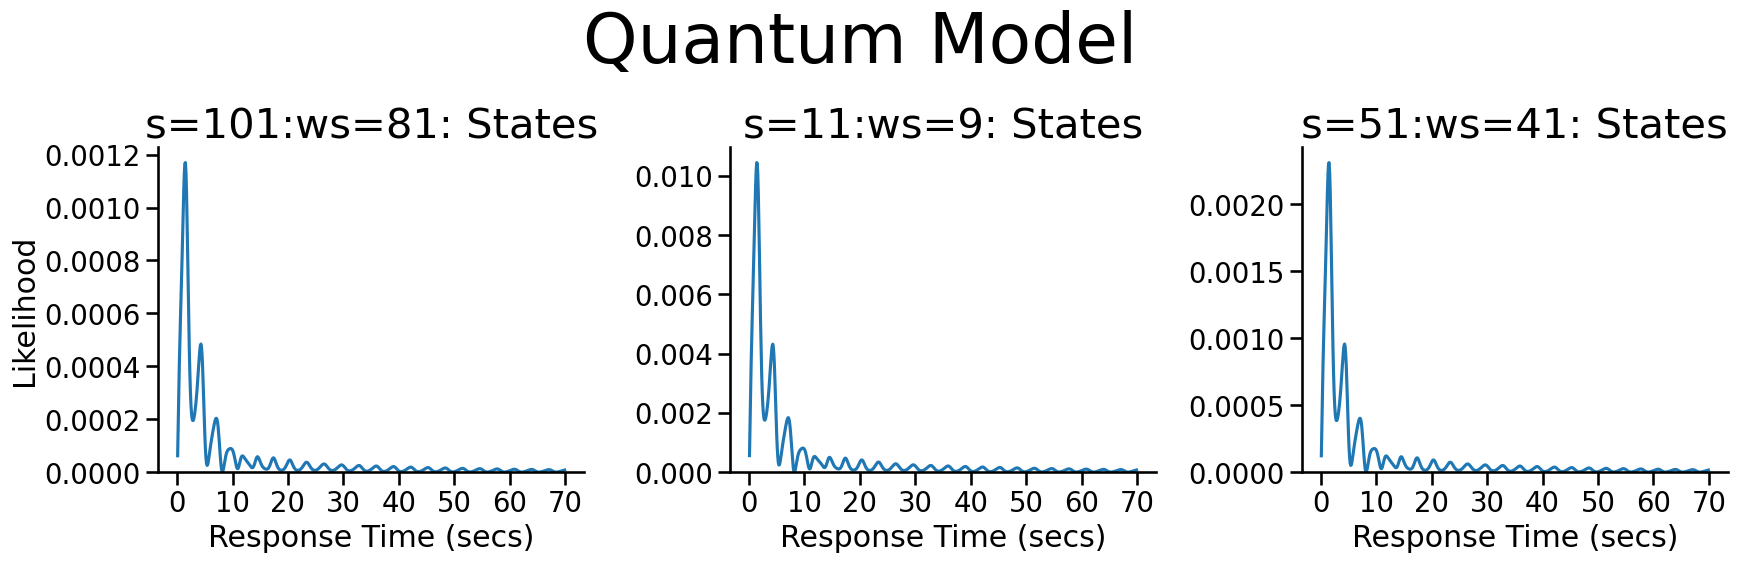

In [99]:
with sns.plotting_context("talk", font_scale=1.2):
    f = sns.relplot(df_quantum_plot_n1.query("prob==0.5 and ws_n=='All Non-Response States'").assign(states_ws = lambda df: "s="+df.states.astype(str) +":ws=" +(df.ws.astype(int)*2+1).astype(str)).astype({"states_ws":"category"}),
    x="time", y="likl_ts", col="states_ws", kind="line", facet_kws={"sharey":False, "sharex":False},
    aspect=1.2)
    f.figure.suptitle("Quantum Model", fontsize=50,y=1.15)
    f.set_titles("{col_name}: States",size=30)
    f.set(ylim=(0,None))
    f.set_axis_labels(x_var="Response Time (secs)", y_var="Likelihood")
    #f.legend.set_title("States Interfering")

/tmp/ipykernel_8019/1311807853.py:2: RuntimeWarning:

Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.



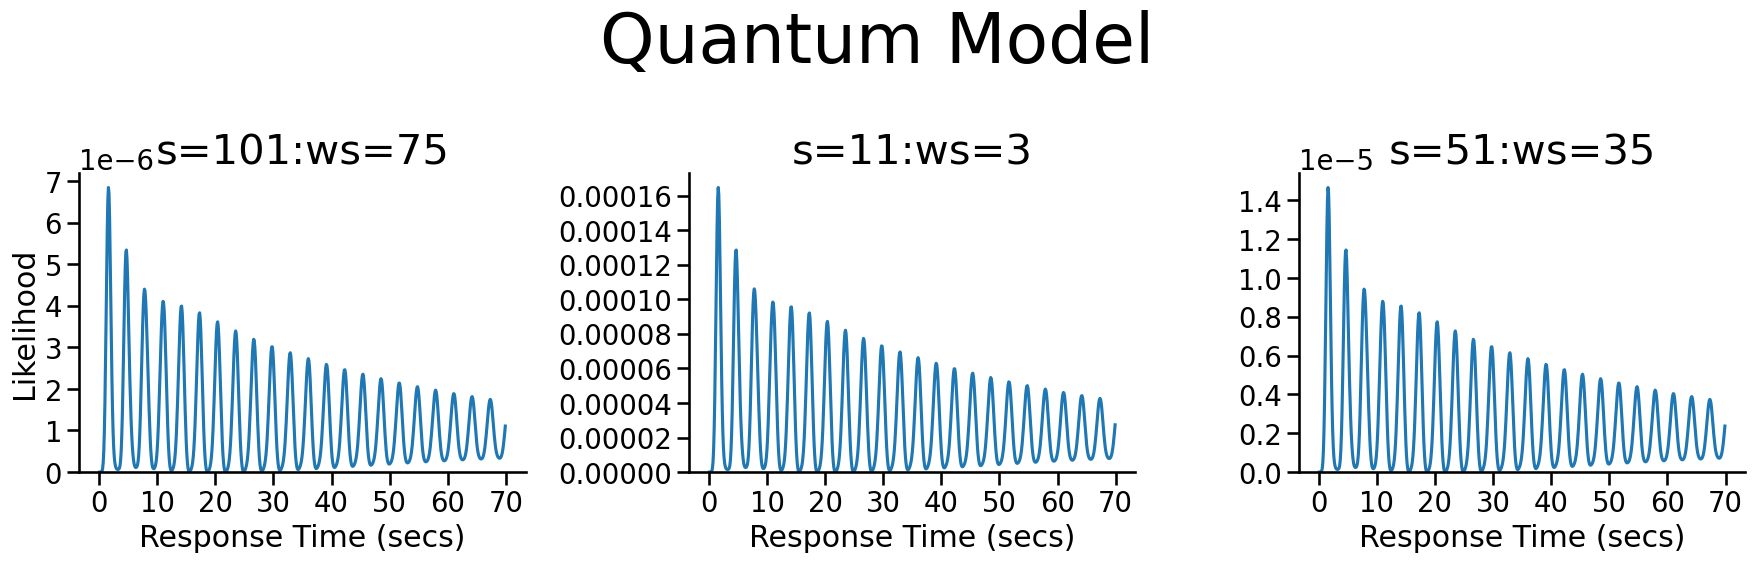

In [100]:
with sns.plotting_context("talk", font_scale=1.2):
    f = sns.relplot(df_quantum_plot_n1.query("prob==0.5 and ws_n=='Fewer Less'").astype({"states":"category"}).assign(states_ws = lambda df: "s="+df.states.astype(str) +":ws=" +(df.ws.astype(int)*2+1).astype(str)).astype({"states_ws":"category"}),
    x="time", y="likl_ts", col="states_ws", kind="line", facet_kws={"sharey":False, "sharex":False},
    aspect=1.2)
    f.figure.suptitle("Quantum Model", fontsize=50,y=1.15)
    f.set_titles("{col_name}",size=30)
    f.set(ylim=(0,None))
    f.set_axis_labels(x_var="Response Time (secs)", y_var="Likelihood")
    #f.legend.set_title("States Interfering")

sns.relplot(df_quantum_plot_n1.query("states==11"),
x="time", y="mc_rt", col="ws_n", kind="line", facet_kws={"sharey":False})

sns.relplot(df_quantum_plot_n1.query("states==11"),
x="time", y="mc_ts", col="ws_n", kind="line", facet_kws={"sharey":False})

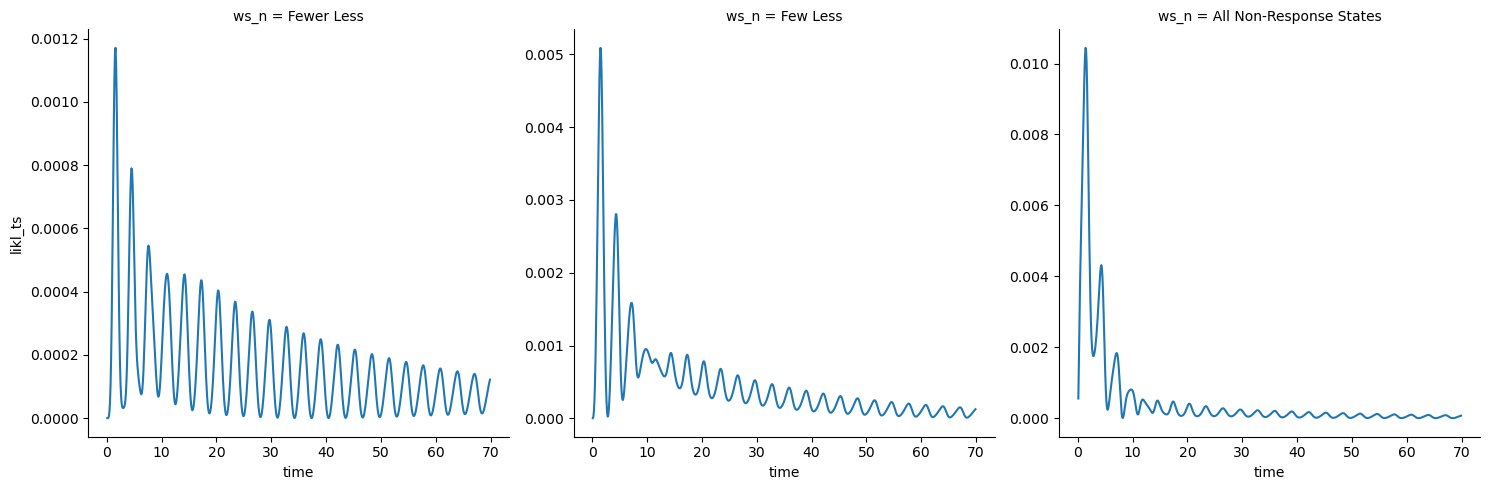

In [29]:
sns.relplot(df_quantum_plot_n1.query("states==11"),
x="time", y="likl_ts", col="ws_n" , kind="line", facet_kws={"sharey":False})

pd.Series(npx.asarray(likl_quantum_arr), name="Quantum").plot()

In [30]:
n_states, start_width, response_width

(11, 5, 6)

In [31]:
df_markov = pd.DataFrame()
df_quantum = pd.DataFrame()
df_quantum_r = pd.DataFrame()
df_quantum_c = pd.DataFrame()
for prior_type in ["Opposite", "Centered", "Lower"]:
    phi_0_markov = ca._get_initial_state(n_states, start_width,response_width, model_type="Markov", prior_type=prior_type)
    phi_0_quantum = ca._get_initial_state(n_states, start_width,response_width, model_type="Quantum" , prior_type=prior_type)

    phi_markov_arr = []
    phi_quantum_arr = []
    phi_quantum_arr_r = []
    phi_quantum_arr_c = []

    phi_markov_arr.append(np.asarray(phi_0_markov.squeeze()))
    phi_quantum_arr.append(np.abs(phi_0_quantum.squeeze())**2)

    #phi_quantum_arr_r.append(np.real(phi_0_quantum.squeeze()))
    #phi_quantum_arr_c.append(np.imag(phi_0_quantum.squeeze()))
    #df_quantum_r = pd.concat([df_quantum_r, pd.DataFrame(phi_quantum_arr_r).T.assign(prior=prior_type)])
    #df_quantum_c = pd.concat([df_quantum_c, pd.DataFrame(phi_quantum_arr_c).T.assign(prior=prior_type)])
    
    for t in np.arange(1,10,delta):
        phi_markov = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")
        phi_markov_arr.append(np.asarray(phi_markov.squeeze()))
    for t in np.arange(1,10,delta):
        phi_quantum = ca.perform_state_transition(intensity_matrix_quantum, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                q_Mc, q_Mw, q_Mn, phi_0_quantum, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")
        phi_quantum_arr.append(np.abs(phi_quantum.squeeze())**2)
        phi_quantum_arr_r.append(np.real(phi_quantum.squeeze()))
        phi_quantum_arr_c.append(np.imag(phi_quantum.squeeze()))
    
    df_markov = pd.concat([df_markov, pd.DataFrame(phi_markov_arr).T.assign(prior=prior_type)])
    df_quantum = pd.concat([df_quantum, pd.DataFrame(phi_quantum_arr).T.assign(prior=prior_type)])
    df_quantum_r = pd.concat([df_quantum_r, pd.DataFrame(phi_quantum_arr_r).T.assign(prior=prior_type)])
    df_quantum_c = pd.concat([df_quantum_c, pd.DataFrame(phi_quantum_arr_c).T.assign(prior=prior_type)])
        

In [39]:
df_quantum_3d = df_quantum_r.melt(id_vars = "prior", ignore_index=False, var_name="time", value_name="real").reset_index(names="states").merge(
df_quantum_c.melt(id_vars = "prior", ignore_index=False, var_name="time", value_name="imag").reset_index(names="states"),
on=["states", "time", "prior"]
).assign(states = lambda df: df.states - n_states//2 )
df_quantum_3d = df_quantum_3d.assign(time=lambda df: df.time * 0.1)
df_quantum_3d

,states,prior,time,real,imag
0,-5,Opposite,0.0,0.12671648537267136,-0.0030539805768429102
1,-4,Opposite,0.0,-0.12057709163672138,-0.07309418924931409
2,-3,Opposite,0.0,-0.13145832566438154,0.01934395052755324
3,-2,Opposite,0.0,-0.15168366843351852,0.13681527098766424
4,-1,Opposite,0.0,0.29999135694933937,-0.03871668769764313
...,...,...,...,...,...
2965,1,Lower,8.9,-0.09780609930079504,0.25310218134088885
2966,2,Lower,8.9,0.18467780600215067,0.006318766603413198
2967,3,Lower,8.9,0.021271133777601044,-0.11303685199522615
2968,4,Lower,8.9,-0.13109514049626514,0.09223257389757075


In [40]:
df_quantum_3d_plot1 = df_quantum_3d.assign(state_labels = lambda df: df.states * 10 + (50 * np.sign(df.states)) ).query("time < 10.24").assign(time = lambda df: df.time * 0.1) \
                 .query("prior == 'Centered' and time < 1").rename(columns={"time":"Time", "real":"Real", "imag":"Imaginary"}) #\
                 #.query("state_labels == -100")

df_quantum_3d_plot1

,states,prior,Time,Real,Imaginary,state_labels
11,-5,Centered,0.0,-0.10197482730366877,0.029835593061171665,-100
12,-4,Centered,0.0,0.048024717224145995,0.04430928693423335,-90
13,-3,Centered,0.0,0.1943857814717478,-0.010895562274463047,-80
14,-2,Centered,0.0,0.06583909854155151,-0.03350635249980464,-70
15,-1,Centered,0.0,0.0017936342871240074,-0.04185213607238707,-60
...,...,...,...,...,...,...
2954,1,Centered,0.89,-0.17621043010909263,-0.21740887577646703,60
2955,2,Centered,0.89,0.3176813354464779,-0.11402189358930273,70
2956,3,Centered,0.89,-0.16339124533547525,-0.08851562381811154,80
2957,4,Centered,0.89,-0.4979828139174458,0.12065776516142439,90


import mpl_toolkits
fig, ax = plt.subplots(subplot_kw=dict(projection='3d'), figsize = (19,9))
for k, df in df_quantum_3d_plot1.groupby("state_labels"):
    ax.plot(df_quantum_3d_plot1.Time, df_quantum_3d_plot1.Real, df_quantum_3d_plot1.Imaginary, label=k)
#mpl_toolkits.mplot3d.art3d.Line3D(df_quantum_3d_plot1.Time, df_quantum_3d_plot1.Real, df_quantum_3d_plot1.Imaginary)
plt.legend()

In [41]:
df_quantum_3d.assign(state_labels = lambda df: df.states * 10 + (50 * np.sign(df.states)) ) \
            .query("time < 10.24") \
            .assign(time = lambda df: df.time * 0.1) \
                 .query("prior == 'Centered' and time < 1").rename(columns={"time":"Time", "real":"Real", "imag":"Imaginary"}).astype(dict(Time=float, Real=float, Imaginary=float)).describe()

,states,Time,Real,Imaginary,state_labels
count,990.000000,990.000000,990.000000,990.000000,990.000000
mean,0.000000,0.445000,0.029822,-0.000126,0.000000
std,3.163876,0.259923,0.222428,0.201585,77.498818
min,-5.000000,0.000000,-0.712246,-0.615426,-100.000000
25%,-3.000000,0.220000,-0.077621,-0.103906,-80.000000
50%,0.000000,0.445000,0.041988,-0.007759,0.000000
75%,3.000000,0.670000,0.156074,0.100298,80.000000
max,5.000000,0.890000,0.737362,0.622035,100.000000


In [42]:
import plotly.express as px

In [43]:
colors = sns.color_palette("husl", 11)
colors

[(0.9677975592919913, 0.44127456009157356, 0.5358103155058701),
 (0.8836443049112893, 0.5240073524369634, 0.19569304285113343),
 (0.710130687316902, 0.6046852192663268, 0.19426060163712158),
 (0.5432776721247529, 0.6540981095185215, 0.19324494273892204),
 (0.19592059105779686, 0.6981620017487838, 0.3452219818913641),
 (0.2067117296964458, 0.6829103404254792, 0.5829988925822328),
 (0.21420912437215422, 0.6714963557258681, 0.6986206664203177),
 (0.22537170008202412, 0.6531400148480775, 0.841007805313343),
 (0.5596943802099308, 0.5764402169887779, 0.9583930713150347),
 (0.8578978803740231, 0.44058452715322166, 0.957819659566579),
 (0.9628653850704806, 0.4025928454059796, 0.7779310354076443)]

import plotly.graph_objects as go
import numpy as np

# Data for the line
df_quantum_3d_plot = df_quantum_3d.assign(state_labels = lambda df: df.states * 10 + (50 * np.sign(df.states)) ).query("time < 10.24").assign(time = lambda df: df.time * 0.1) \
                 .query("prior == 'Centered' and time < 1").rename(columns={"time":"Time", "real":"Real", "imag":"Imaginary"}) \
                 .astype(dict(Time=float, Real=float, Imaginary=float, state_labels="category")) \
                  .query("states == -5")

x = df_quantum_3d_plot.Time
y = df_quantum_3d_plot.Real
z = df_quantum_3d_plot.Imaginary
c = df_quantum_3d_plot.state_labels
t = x

data1 = []
frames1 = []

for (k, df), c in zip(df_quantum_3d_plot.groupby("states"), colors):
    x = df_quantum_3d_plot.Time
    y = df_quantum_3d_plot.Real
    z = df_quantum_3d_plot.Imaginary
    c = df_quantum_3d_plot.state_labels
    t = x
    data1 = data1 + [go.Scatter3d(x=x, y=y, z=z, mode='lines', line=dict(width=3, color=c))]
    frames1 = frames1 + [go.Frame(data=[go.Scatter3d(x=x[:k+1], y=y[:k+1], z=z[:k+1])]) for k in range(len(t))]

#px.scatter_3d(df_quantum_3d_plot, x="Time", y="Real", z="Imaginary", animation_frame="Time", animation_group="Time",
#           color="state_labels", 
#           range_x=[0, 0.9], range_y=[-0.8, 0.8], range_z=[-0.7, 0.7])

# Create the figure
fig = go.Figure(
    data= data1,
    layout=go.Layout(
        scene=dict(
            yaxis=dict(range=[-0.8, 0.8]),
            zaxis=dict(range=[-0.7, 0.7]),
            xaxis=dict(range=[0, 0.9]),
        ),
        title="Animated 3D Line Plot",
        updatemenus=[dict(
            type="buttons",
            buttons=[dict(label="Play",
                          method="animate",
                          args=[None, {"frame": {"duration": 50, "redraw": True},
                                        "fromcurrent": True, "transition": {"duration": 0}}])])]),
)

# Create frames for the animation
frames = frames1

fig.frames = frames

fig.show()

In [44]:


pio.renderers.default = "vscode" #"browser" #
fig = px.line_3d(df_quantum_3d.assign(state_labels = lambda df: df.states * 10 + (50 * np.sign(df.states)) ).query("time < 10.24").assign(time = lambda df: df.time * 0.1) \
                 .query("prior == 'Centered' and time < 1").rename(columns={"time":"Time", "real":"Real", "imag":"Imaginary"}), 
                 x="Time", y="Real", z="Imaginary", color="state_labels", 
                 title = 'Random Walk - Probability "Amplitude" (Participant #1)',
                 range_x=[0,1], range_y=[-0.6, 0.6], range_z=[-0.6, 0.6],#animation_frame="Time", animation_group="state_labels",
labels = {"real":"Real", "imag": "Imaginary"}
)
fig.update_layout(legend_title = "Conf States", 
    scene=dict(aspectratio = dict( x=2.5, y=1, z=1 ),
    aspectmode = 'manual'),
    autosize=True
    )
fig.update_traces(line=dict(
        width=10
    ))
fig.update_layout(
    legend_title_font=dict(size=50, color="black"),
    title_font=dict(size=60, color="black"),
    font=dict(
        
        size=20,  # Set the font size here
    ))
fig.update_scenes(
    xaxis=dict(title='Observed time (in secs)', tickfont=dict(size=15), titlefont=dict(size=45)),
    yaxis=dict(title='Real', tickfont=dict(size=15), titlefont=dict(size=45)),
    zaxis=dict(title='Imaginary', tickfont=dict(size=15), titlefont=dict(size=45)),
)
fig.layout.template = "seaborn"
#fig.show()
#import plotly.io as pio
#pio.write_image(fig, 'image.png',format="png",scale=1, width=1080, height=1080)

In [45]:
df_markov_plot = df_markov.melt(id_vars = "prior", ignore_index=False, var_name="time").assign(time = lambda df:df.time*delta).reset_index(names="states").assign(states = lambda df: df.states - n_states//2 )
df_quantum_plot = df_quantum.melt(id_vars = "prior", ignore_index=False, var_name="time").assign(time = lambda df:df.time*delta).reset_index(names="states").assign(states = lambda df: df.states - n_states//2)
#df_markov_plot = df_markov_plot.assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "Centered":"Centered"}))
#df_quantum_plot = df_quantum_plot.assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "Centered":"Centered"}))

df_markov_plot = df_markov_plot.assign(prior = lambda df:df.prior.map({"Opposite":"Opposite", "Lower":"-High", "Centered":"Centered"}))
df_quantum_plot = df_quantum_plot.assign(prior = lambda df:df.prior.map({"Opposite":"Opposite", "Lower":"-High", "Centered":"Centered"}))

In [46]:
tau, m_mu, sigma_coef[0], m_sigma[0][0]

(0.01, Array([[1]], dtype=int64), 1, Array(1, dtype=int64))

In [47]:
theta1, mu1, sigma1 = theta, np.array([[2]]), m_sigma[0][0] #to get 107 states
#theta1 = theta

In [48]:
RT_arr, X_arr, steps_arr = drw.gen_rt_x(theta1, alpha, tau, sigma1, mu1, samples = 50, process="Wiener", initial="EZ", njobs=1, scale_steps_to_boundary=False)
np.asarray(RT_arr)

array([0.21, 0.45, 0.75, 1.17, 0.45, 0.16, 0.03, 0.04, 0.27, 0.06, 0.49,
       0.54, 0.1 , 0.14, 0.24, 0.07, 0.09, 0.79, 0.19, 0.37, 0.23, 0.14,
       0.05, 0.13, 0.14, 0.06, 0.07, 0.34, 0.21, 0.19, 0.1 , 0.54, 0.74,
       0.14, 0.36, 0.2 , 0.15, 0.4 , 0.06, 0.07, 0.18, 0.21, 0.23, 0.24,
       0.08, 0.24, 0.13, 0.26, 0.11, 0.15])

In [49]:
np.asarray(X_arr)

array([1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 0, 1])

In [50]:
df_t = pd.DataFrame({"steps":np.asarray(steps_arr[0])}).reset_index(names="time").assign(time = lambda df: df.time * tau)
df_t

,time,steps
0,0.00,0
1,0.01,-1
2,0.02,0
3,0.03,1
4,0.04,1
5,0.05,2
6,0.06,2
7,0.07,1
8,0.08,2
9,0.09,2


df_markov_plot.query("time >= 96")

sns.scatterplot(df_markov_plot
                    .query("time >= 96"),
                    alpha=0.8, 
    x="time", y="states",size="value", color="Black")

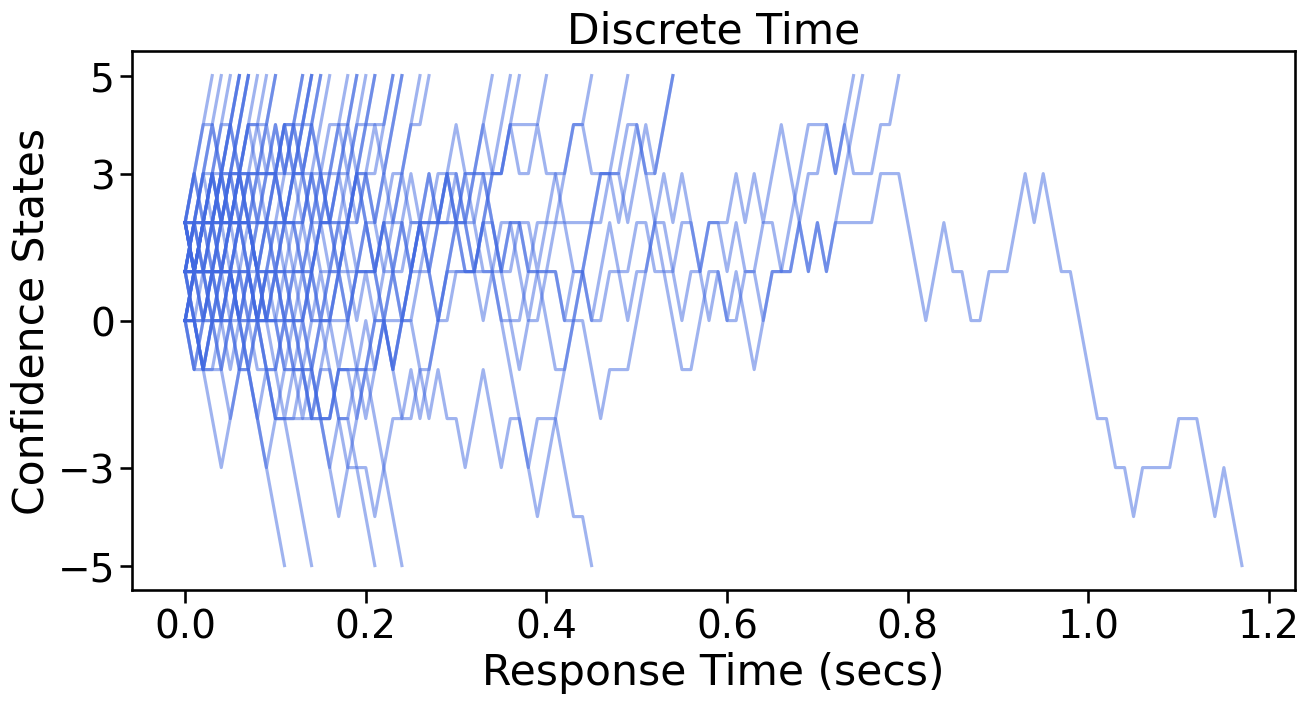

In [51]:
with sns.plotting_context("talk", font_scale=1.7):
    for st in steps_arr:
        df_t = pd.DataFrame({"steps":np.asarray(st)}).reset_index(names="time").assign(time = lambda df: df.time * tau)
        f = sns.lineplot(df_t,
        x="time", color="royalblue", alpha=0.5,
        y="steps")
        f.set_ylabel("Confidence States")
        f.set_xlabel("Response Time (secs)")
        f.set_title("Discrete Time")
        f.figure.set_size_inches(15,7)
        

f.set_yticks([-5,-3,0,3,5])

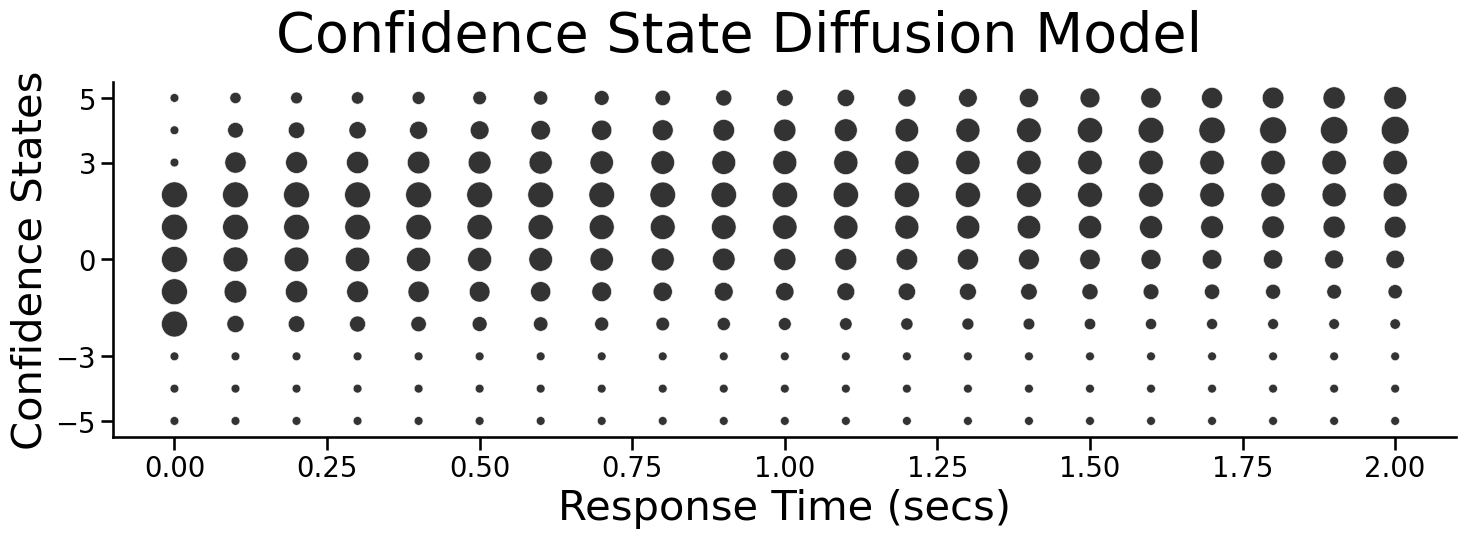

In [52]:
with sns.plotting_context("talk", font_scale=1.2):
    f = sns.relplot(df_markov_plot.assign(model="Diffusion")
                        .query("time <= 2 and prior == 'Centered'")
                        ,alpha=0.8, legend=False, aspect=3,
        x="time", y="states",size="value", sizes=(40,400), color="Black")
    f.set(yticks=[-5,-3,0,3,5])
    f.figure.suptitle("Confidence State Diffusion Model", fontsize=40, y=1.08)
    f.set_ylabels("Confidence States", fontsize=30)
    f.set_xlabels("Response Time (secs)", fontsize=30)

/tmp/ipykernel_1203819/2980448637.py:22: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



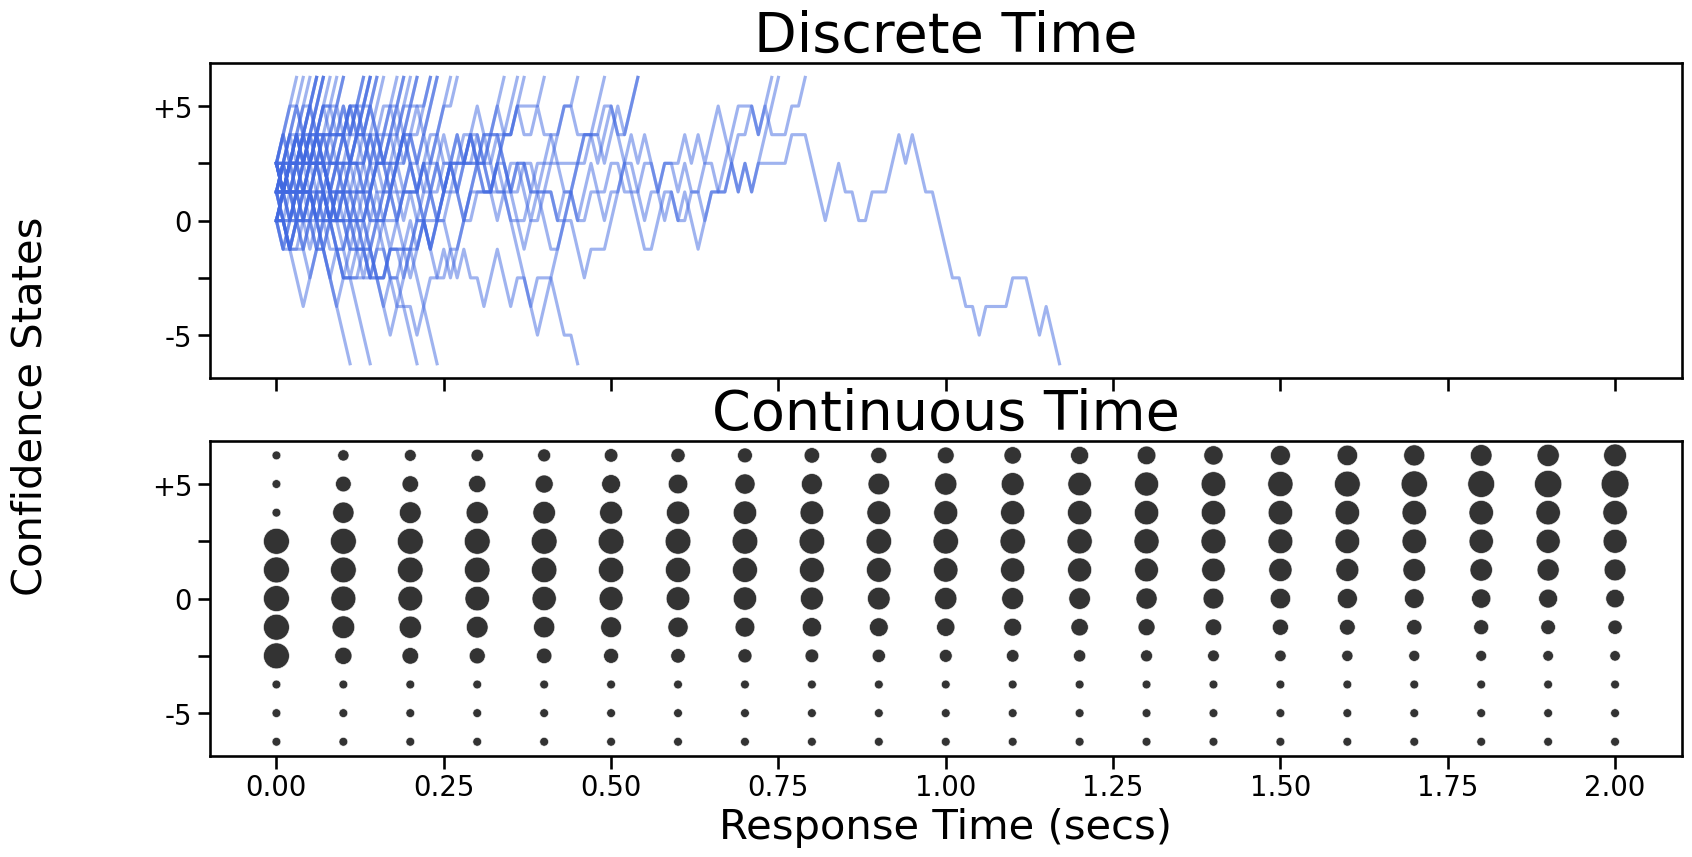

In [53]:


with sns.plotting_context("talk", font_scale=1.2):
    fig, axs = plt.subplots(2,1, figsize=(19,9), sharey=True, sharex=True)
    for st in steps_arr:
        df_t = pd.DataFrame({"steps":np.asarray(st)}).reset_index(names="time").assign(time = lambda df: df.time * tau)
        f = sns.lineplot(df_t,
        x="time", color="royalblue", alpha=0.5,
        y="steps", ax=axs[0])
        f.set_ylabel("", fontsize=2)
        f.set_xlabel("Response Time (secs)")
        f.set_title("Discrete Time", fontsize=40)
    f = sns.scatterplot(df_markov_plot.assign(model="Diffusion")
                        .query("time <= 2 and prior == 'Centered'")
                        ,alpha=0.8, ax=axs[1], legend=False,
        x="time", y="states",size="value", sizes=(40,400), color="Black")

    #f.legend.set_title("Prob")
    f.set_xlabel("Response Time (secs)", fontsize=30)
    f.set_ylabel("", fontsize=2)
    f.figure.supylabel("Confidence States", fontsize=30)
    f.set_title("Continuous Time", fontsize=40)
    #f.set_ylabels("Conf States")
    f.set_yticklabels(["","-5","","0","","+5"])    
    #f.legend(title="Prob", bbox_to_anchor=(1.009,0.9))


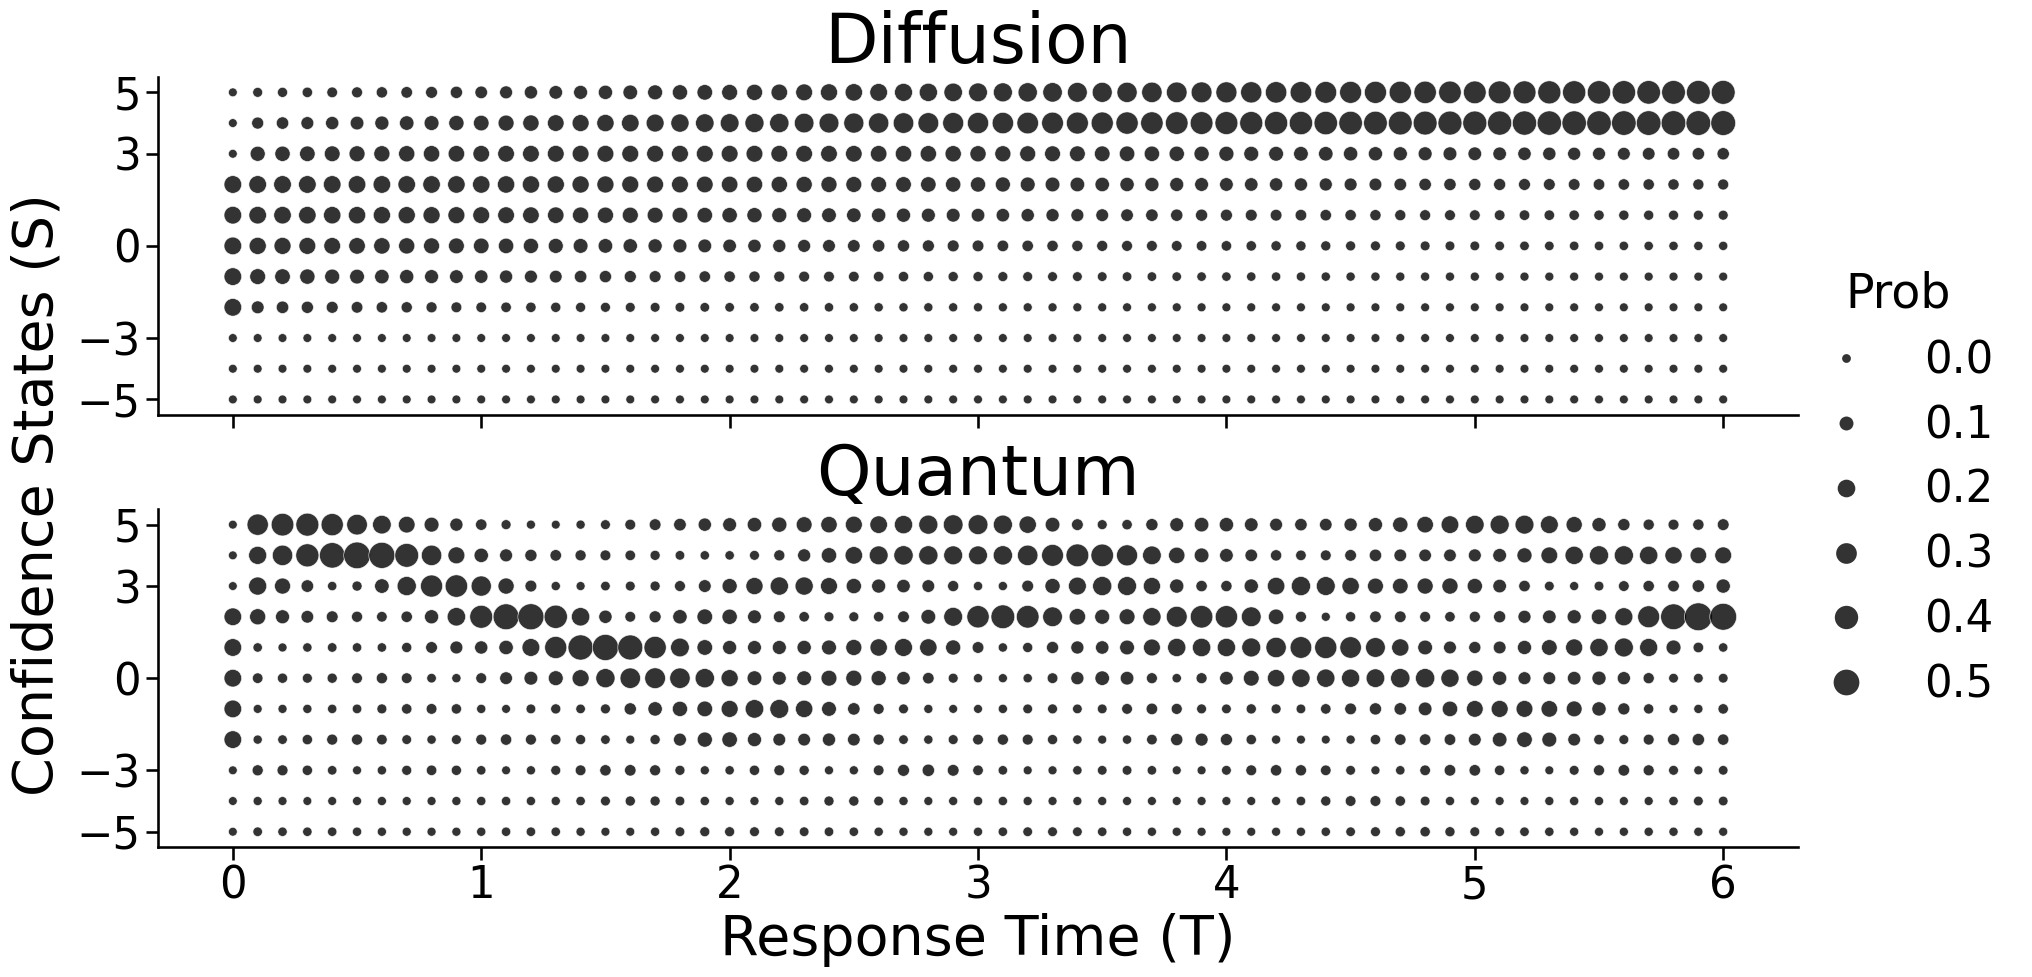

In [54]:
with sns.plotting_context("talk", font_scale=1.9, rc={'axes.labelsize':50, 'font.size': 10.0,}):
    f = sns.relplot(pd.concat([df_markov_plot.assign(model="Diffusion"), df_quantum_plot.assign(model="Quantum")])
                    .query("time <= 6 and prior == 'Centered'")
                    ,alpha=0.8, row="model", 
    x="time", y="states",size="value", sizes=(40,400), color="Black", aspect=3.7, height=5)
    f.set_titles("{row_name}")
    f.legend.set_title("Prob")
    f.set_xlabels("Response Time (T)", fontsize=40)
    f.set_ylabels("", fontsize=40)
    #f.set(ylim=(-5.5, 5.5))
    #f.set_yticklabels(["-5","","0","","+5"]) 
    f.set(yticks=[-5,-3,0,3,5])
    f.figure.supylabel("Confidence States (S)", fontsize=40)

In [56]:
n_states, start_width,response_width

(11, 5, 6)

In [57]:
df_markov = pd.DataFrame()
df_quantum = pd.DataFrame()
df_quantum_r = pd.DataFrame()
df_quantum_c = pd.DataFrame()
m_mu_arr, m_sigma, T = [npx.asarray([[0.1]]), npx.asarray([[1]]), npx.asarray([[2]]), npx.asarray([[3]])], npx.asarray([[3]]), 40
q_mu_arr, q_sigma, T = [npx.asarray([[0.1]]), npx.asarray([[1]]), npx.asarray([[2]]), npx.asarray([[3]])], npx.asarray([[3]]), 40


for m_mu, q_mu in zip(m_mu_arr, q_mu_arr):
    intensity_matrix_markov = dd._buildK(n_states, m_mu, m_sigma)
    intensity_matrix_quantum = qd._buildH(n_states, q_mu, q_sigma)
    for prior_type in ["Opposite", "Centered", "Lower"]:
        phi_0_markov = ca._get_initial_state(n_states, start_width,response_width,model_type="Markov", prior_type=prior_type)
        phi_0_quantum = ca._get_initial_state(n_states, start_width,response_width,model_type="Quantum" , prior_type=prior_type)

        phi_markov_arr = []
        phi_quantum_arr = []
        phi_quantum_arr_r = []
        phi_quantum_arr_c = []

        phi_markov_arr.append(np.asarray(phi_0_markov.squeeze()))
        phi_quantum_arr.append(np.abs(phi_0_quantum.squeeze())**2)

        #phi_quantum_arr_r.append(np.real(phi_0_quantum.squeeze()))
        #phi_quantum_arr_c.append(np.imag(phi_0_quantum.squeeze()))
        #df_quantum_r = pd.concat([df_quantum_r, pd.DataFrame(phi_quantum_arr_r).T.assign(prior=prior_type)])
        #df_quantum_c = pd.concat([df_quantum_c, pd.DataFrame(phi_quantum_arr_c).T.assign(prior=prior_type)])
        
        for t in np.arange(1,T,delta):
            phi_markov = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                    m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                    transition_type="RT", likelihood_type="SINGLE")
            phi_markov_arr.append(np.asarray(phi_markov.squeeze()))
        for t in np.arange(1,T,delta):
            phi_quantum = ca.perform_state_transition(intensity_matrix_quantum, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                    q_Mc, q_Mw, q_Mn, phi_0_quantum, delta, 
                                                    transition_type="RT", likelihood_type="SINGLE")
            phi_quantum_arr.append(np.abs(phi_quantum.squeeze())**2)
                  
        df_markov = pd.concat([df_markov, pd.DataFrame(phi_markov_arr).T.assign(prior=prior_type, mu=m_mu[0,0].item())])
        df_quantum = pd.concat([df_quantum, pd.DataFrame(phi_quantum_arr).T.assign(prior=prior_type, mu=q_mu[0,0].item())])
        
        

In [58]:
df_markov.melt(id_vars = ["prior", "mu"], ignore_index=False, var_name="time")#.assign(time = lambda df:df.time*delta)

,prior,mu,time,value
0,Opposite,0.1,0,1.666667e-01
1,Opposite,0.1,0,1.666667e-01
2,Opposite,0.1,0,1.666667e-01
3,Opposite,0.1,0,0.000000e+00
4,Opposite,0.1,0,0.000000e+00
...,...,...,...,...
6,Lower,3.0,390,8.361251e-17
7,Lower,3.0,390,1.523578e-16
8,Lower,3.0,390,9.857752e-17
9,Lower,3.0,390,5.000000e-01


In [59]:
df_markov_plot1 = df_markov.melt(id_vars = ["prior", "mu"], ignore_index=False, var_name="time").assign(time = lambda df:df.time*delta).reset_index(names="states").assign(states = lambda df: df.states - n_states//2 )
df_quantum_plot1 = df_quantum.melt(id_vars = ["prior", "mu"], ignore_index=False, var_name="time").assign(time = lambda df:df.time*delta).reset_index(names="states").assign(states = lambda df: df.states - n_states//2)
#df_markov_plot1 = df_markov_plot1.assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "Centered":"Centered"}))
#df_quantum_plot1 = df_quantum_plot1.assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "Centered":"Centered"}))

df_markov_plot1 = df_markov_plot1.assign(prior = lambda df:df.prior.map({"Opposite":"Opposite", "Lower":"-High", "Centered":"Centered"}))
df_quantum_plot1 = df_quantum_plot1.assign(prior = lambda df:df.prior.map({"Opposite":"Opposite", "Lower":"-High", "Centered":"Centered"}))

In [60]:
df_conf_plot = pd.concat([df_markov_plot1.assign(model="Diffusion"), df_quantum_plot1.assign(model="Quantum")])
df_conf_plot= df_conf_plot.groupby(["prior", "mu", "time", "model"])["value"].apply(lambda ds: (mv_arr*ds).sum()).reset_index(name="conf_state")
df_conf_plot

,prior,mu,time,model,conf_state
0,-High,0.1,0.0,Diffusion,-3.000000
1,-High,0.1,0.0,Quantum,-3.000000
2,-High,0.1,0.1,Diffusion,-2.494887
3,-High,0.1,0.1,Quantum,-1.847905
4,-High,0.1,0.2,Diffusion,-2.451581
...,...,...,...,...,...
9379,Opposite,3.0,38.8,Quantum,0.826364
9380,Opposite,3.0,38.9,Diffusion,4.500000
9381,Opposite,3.0,38.9,Quantum,0.858267
9382,Opposite,3.0,39.0,Diffusion,4.500000


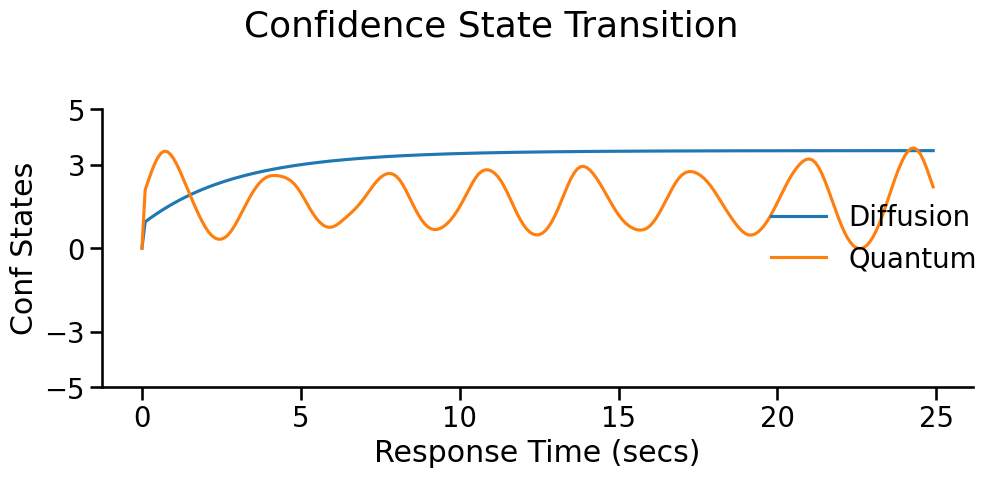

In [61]:
with sns.plotting_context("talk", font_scale=1.2):
    f = sns.relplot(df_conf_plot.query("mu==1 and time < 25"), x="time", y="conf_state", col="prior",hue="model", kind="line",
                col_order=["Centered"], aspect=1.6
                )
    f.legend.set_title("")
    f.set_titles("")#("Initial Confidence: {col_name}")
    f.set_xlabels("Response Time (secs)")
    f.set_ylabels("Conf States")
    f.set(yticks=[-5,-3,0,3,5])
    f.figure.suptitle("Confidence State Transition")
    plt.tight_layout()

In [62]:
df_conf_plot1 = pd.concat([df_markov_plot1.assign(model="Diffusion"), df_quantum_plot1.assign(model="Quantum")]).query("mu==2")
df_conf_plot2 = df_conf_plot1.groupby(["prior", "mu", "time", "model"])["value"].apply(lambda ds: (mv_arr*ds).sum()).reset_index(name="conf_state")
df_conf_plot3 = df_conf_plot1.set_index(["prior", "mu", "time", "model"]).join(df_conf_plot2.set_index(["prior", "mu", "time", "model"])).reset_index()
df_conf_plot3

,prior,mu,time,model,states,value,conf_state
0,-High,2.0,0.0,Diffusion,-5,0.200000,-3.000000
1,-High,2.0,0.0,Diffusion,-4,0.200000,-3.000000
2,-High,2.0,0.0,Diffusion,-3,0.200000,-3.000000
3,-High,2.0,0.0,Diffusion,-2,0.200000,-3.000000
4,-High,2.0,0.0,Diffusion,-1,0.200000,-3.000000
...,...,...,...,...,...,...,...
25801,Opposite,2.0,39.0,Quantum,1,0.169642,1.209902
25802,Opposite,2.0,39.0,Quantum,2,0.010770,1.209902
25803,Opposite,2.0,39.0,Quantum,3,0.056163,1.209902
25804,Opposite,2.0,39.0,Quantum,4,0.202563,1.209902


In [63]:
df_conf_plot3.groupby(["time", "states", "value", "model"]).count()

prior  mu  conf_state
time states value    model                           
0.0  -5     0.000000 Diffusion      1   1           1
                     Quantum        1   1           1
            0.166667 Diffusion      1   1           1
                     Quantum        1   1           1
            0.200000 Quantum        1   1           1
...                               ...  ..         ...
39.0  5     0.179689 Quantum        1   1           1
            0.233732 Quantum        1   1           1
            0.400000 Diffusion      1   1           1
                     Diffusion      1   1           1
                     Diffusion      1   1           1

[25790 rows x 3 columns]

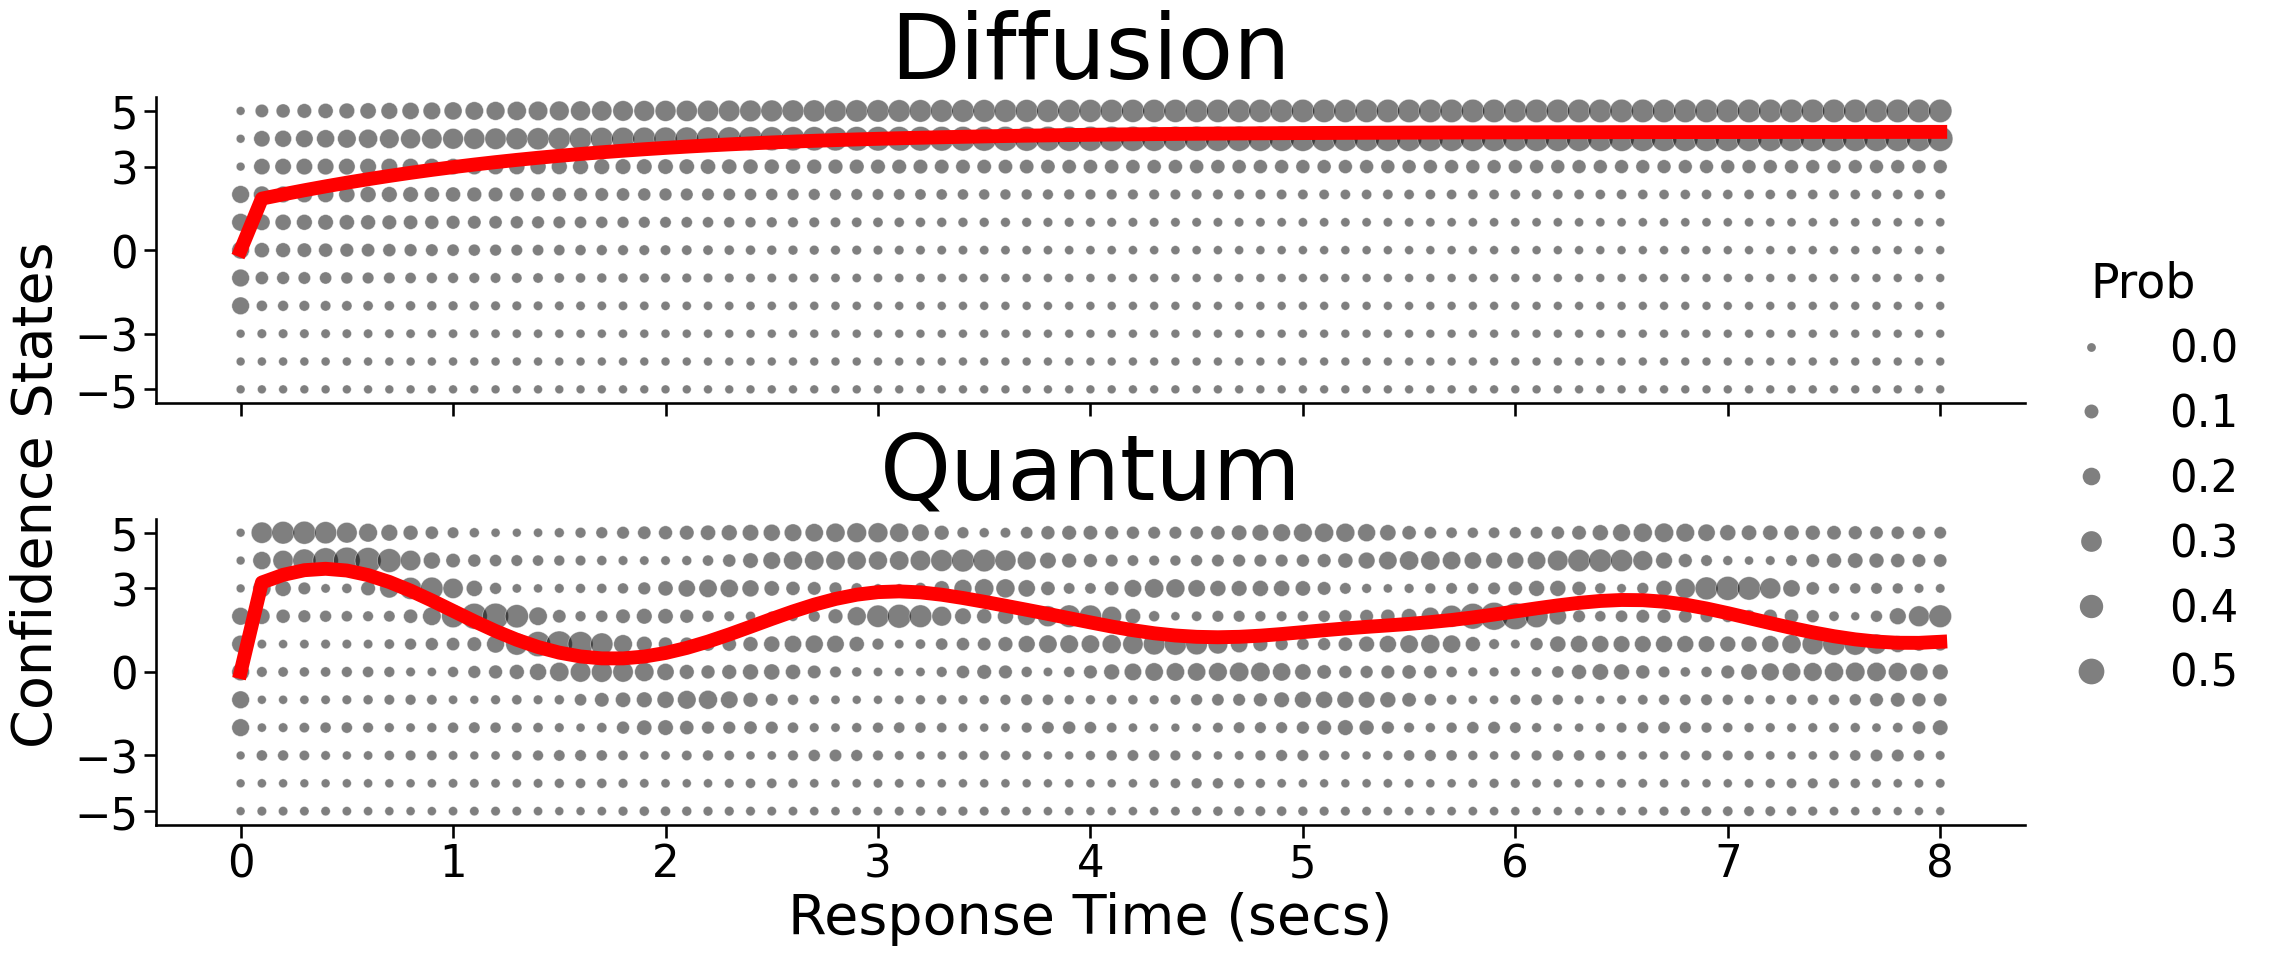

In [64]:
with sns.plotting_context("talk",font_scale=1.9, rc={'axes.labelsize':65, 'font.size': 10.0,}):
    f = sns.relplot(df_conf_plot3
                    .query("time <= 8 and prior == 'Centered'")
                    ,alpha=0.5, row="model", 
    x="time", y="states",size="value", sizes=(40,400), color="Black", aspect=4.2, height=5)
    f.set_titles("{row_name}")
    f.legend.set_title("Prob")
    
    #f.set(ylim=(-5.5, 5.5))
    #f.set_yticklabels(["-5","","0","","+5"]) 
    f.set(yticks=[-5,-3,0,3,5])

    f.map_dataframe(sns.lineplot,
        data = df_conf_plot3
                        .query("time <= 8 and prior == 'Centered'"),
                        lw=10, color="red",
        x="time", y="conf_state")
    f.set_xlabels("Response Time (secs)", fontsize=40)
    f.set_ylabels("", fontsize=40)
    f.figure.supylabel("Confidence States", fontsize=40)

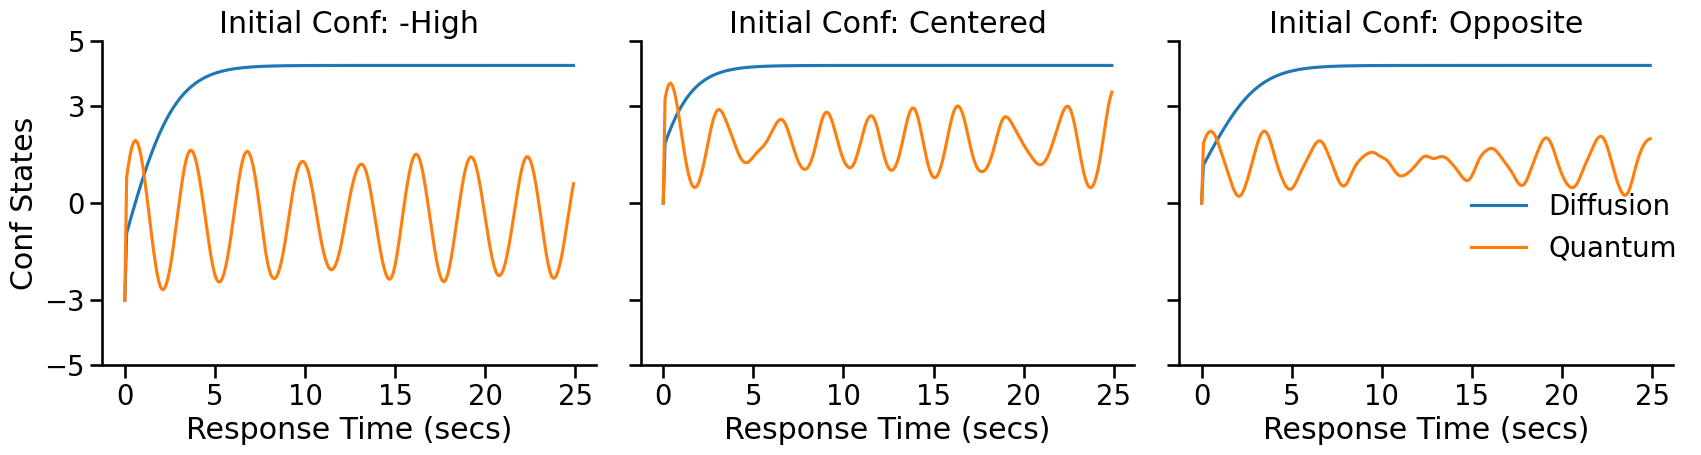

In [65]:
with sns.plotting_context("talk", font_scale=1.2):
    f = sns.relplot(df_conf_plot.query("mu==2 and time < 25"), x="time", y="conf_state", col="prior",hue="model", kind="line",
                col_order=["-High", "Centered", "Opposite"]
                )
    f.legend.set_title("")
    f.set_titles("Initial Conf: {col_name}")
    f.set_xlabels("Response Time (secs)")
    f.set_ylabels("Conf States")
    f.set(yticks=[-5,-3,0,3,5])
    plt.tight_layout()

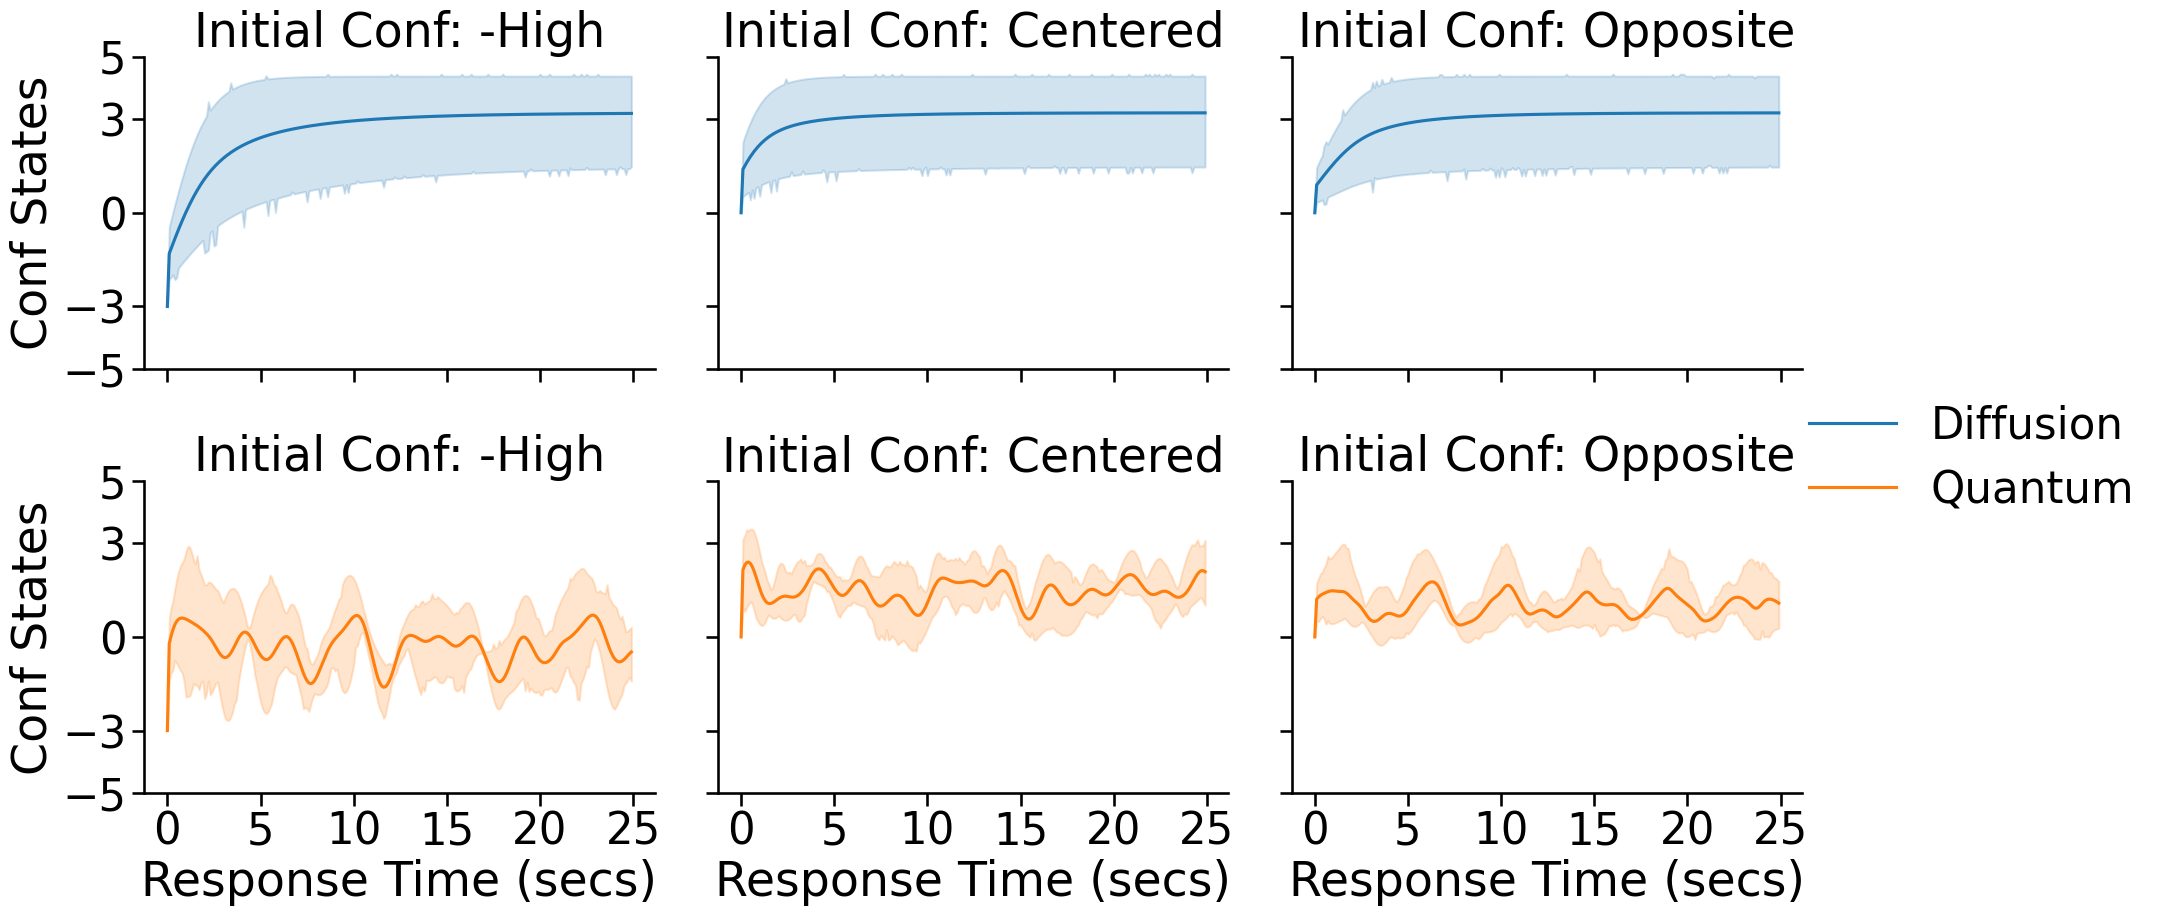

In [66]:
with sns.plotting_context("talk", font_scale=1.9):
    f = sns.relplot(df_conf_plot.query("time < 25"), x="time", y="conf_state", col="prior",hue="model", kind="line",
                col_order=["-High", "Centered", "Opposite"], row="model", aspect=1.3
                )
    f.legend.set_title("")
    f.set_titles("Initial Conf: {col_name}")
    f.set_xlabels("Response Time (secs)")
    f.set_ylabels("Conf States")
    f.set(yticks=[-5,-3,0,3,5])
    #plt.tight_layout()